### Librerías 

In [1]:
import pandas as pd
import networkx as nx
import numpy as np
from collections import defaultdict
import time, json, os, re
import scipy.sparse as sp
import gurobipy as gp
from gurobipy import GRB

### Funciones

In [2]:
from funciones import obtener_comunas, dist, obtener_region, resultados_sampleo, ensure_dir, safe_attr, parse_x_name, extraer_y_guardar_modelo, matriz_X_desde_modelo, promedio_X, comparar_con_baseline

### Data

In [3]:
from chile_data import regiones

### Importamos modelos

In [4]:
from modelos import modelo_con_limite, modelo_centros_fijos_con_limite, modelo_relajado, modelo_relajado_2

In [5]:
comunas=pd.read_excel('comunas.xlsx')
distancias=pd.read_excel('distancias.xlsx')

In [6]:

# R ES UNA LISTA DE COMUNAS, LAS COMUNAS QUE SERÁN PARTE SE DEFINEN A TRAVÉS DE SI 
# LA REGIÓN A LA QUE PERTENECE ESTARÁ INCLUIDA O NO
R = sum([obtener_comunas(comunas, region) for region in regiones], [])

In [7]:
# SE CREA dict_ady_com. ES UN DICCIONARIO DONDE ESTA CADA UNA DE LAS COMUNAS CON SUS ADYACENCIAS
with open('adyacencia_comunas.txt', 'r') as dict_file:
    text_dicc = dict_file.read()
    dict_ady_com = eval(text_dicc)

# SE CREA EL GRAFO DE ADYACENCIA A PARTIR DEL DICCIONARIO
grafo_adyacencia = nx.Graph()
id_local = []
for comuna, adyacencia in dict_ady_com.items():
  id_local.append(comuna)
  for comuna_ady in adyacencia:
    grafo_adyacencia.add_edge(comuna,comuna_ady, weight=dist(distancias, comuna,comuna_ady))

# SE TRABAJA EN UNA MATRIZ CON UN 1 SI LAS COMUNAS SON ADYACENTES, 0 SI NO.
matrix_adyacencia = nx.adjacency_matrix(grafo_adyacencia)
m_ady=np.matrix(matrix_adyacencia.toarray())
matriz_ady=np.matrix.round(m_ady)

In [8]:

# SE CARGA EL PREPROCESAMIENTO DE S COMO DICCIONARIO,
# DE FORMA QUE DESPUÉS SOLO SE DEBA ACCEDER A LOS VALORES Y NO GENERARLOS EN CADA ITERACIÓN
with open('s_nuevo.txt', 'r') as dict_file:
    dict_text = dict_file.read()
    dict_s = eval(dict_text)

# SE CREA UN DICCIONARIO PARA SABER LAS COMUNAS DE CADA UNA DE LAS REGIONES.
comunas_por_region = {}
# Iterar sobre la lista de comunas y asignarlas a las regiones correspondientes
for comuna in R:
    region = obtener_region(comunas, comuna)
    # Verificar si la región ya está en el diccionario, si no, agregarla
    if region not in comunas_por_region:
        comunas_por_region[region] = []
    # Agregar la comuna a la lista de comunas de la región
    comunas_por_region[region].append(comuna)

In [9]:
modelo_con_limite = modelo_con_limite(0.8398, R, 28, dict_s, comunas)

Set parameter Username
Set parameter LicenseID to value 2661041
Academic license - for non-commercial use only - expires 2026-05-05
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-1355U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 256545 rows, 120062 columns and 761890 nonzeros
Model fingerprint: 0x01b9fdce
Coefficient statistics:
  Matrix range     [1e+00, 1e+06]
  Objective range  [0e+00, 0e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 3e+01]
Presolve removed 219366 rows and 109658 columns
Presolve time: 1.35s
Presolved: 10380 rows, 37224 columns, 104408 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 1.07s

Barrier statistics:
 Dense cols : 1
 Free vars  : 319
 AA' NZ     : 3.640e+05
 Factor NZ  : 4.954e+06 (roughly 60 MB of me

In [11]:
vars_mod_lim = modelo_con_limite.getVars()
x1 = np.array([v.X for v in vars_mod_lim], dtype=float)


In [12]:
y_star = {v.VarName.split('[')[1].split(']')[0]: v.x
          for v in modelo_con_limite.getVars() if 'centros_j' in v.VarName}


In [50]:
modelo_rel = modelo_relajado(epsilon=0.8398, R=R, K=28, comunas=comunas, y_star=y_star)



Modelo relajado factible


In [51]:
vars_rel = modelo_rel.getVars()
x1 = np.array([v.X for v in vars_rel], dtype=float)


In [52]:
print("Dimensión de x1:", x1.shape)

Dimensión de x1: (119716,)


----- Resultados para Systematic Sampling -----

Hay 22 centros fijados por el Modelo

Hay 14 comunas con peso positivo

Se realizarán 3000 sampleos para obtener 6 comunas en cada sampleo



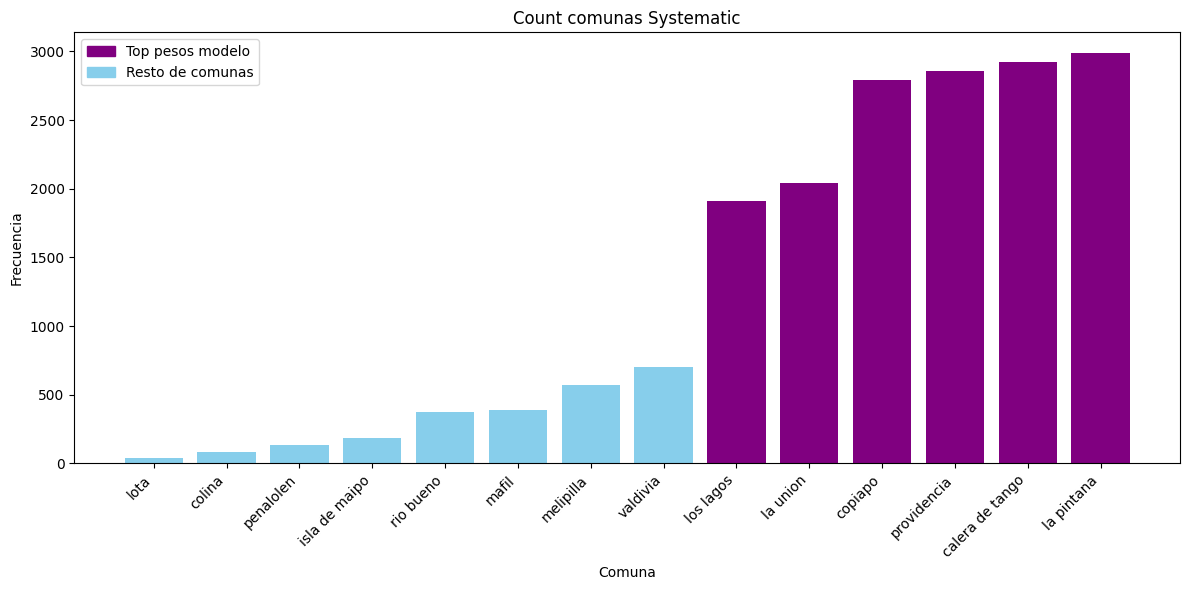

In [10]:
frecuencias_ordenadas_systematic, conteo_systematic, esperanza_empirica_systematic = resultados_sampleo(modelo_con_limite, 28, 3000, "systematic")

In [14]:
esperanza_empirica_systematic

,Comuna,Esperanza Empírica,Peso Gurobi
0,lota,0.009667,0.009228
1,colina,0.019000,0.024169
2,penalolen,0.031667,0.037213
3,isla de maipo,0.055667,0.059105
4,rio bueno,0.111000,0.117569
5,mafil,0.113333,0.117569
6,melipilla,0.173333,0.172293
7,valdivia,0.235000,0.235139
8,los lagos,0.651667,0.647292
9,la union,0.705667,0.704188


### Pruebas

----- Resultados para Pivotal Sampling -----

Hay 22 centros fijados por el Modelo

Hay 14 comunas con peso positivo

Se realizarán 3000 sampleos para obtener 6 comunas en cada sampleo



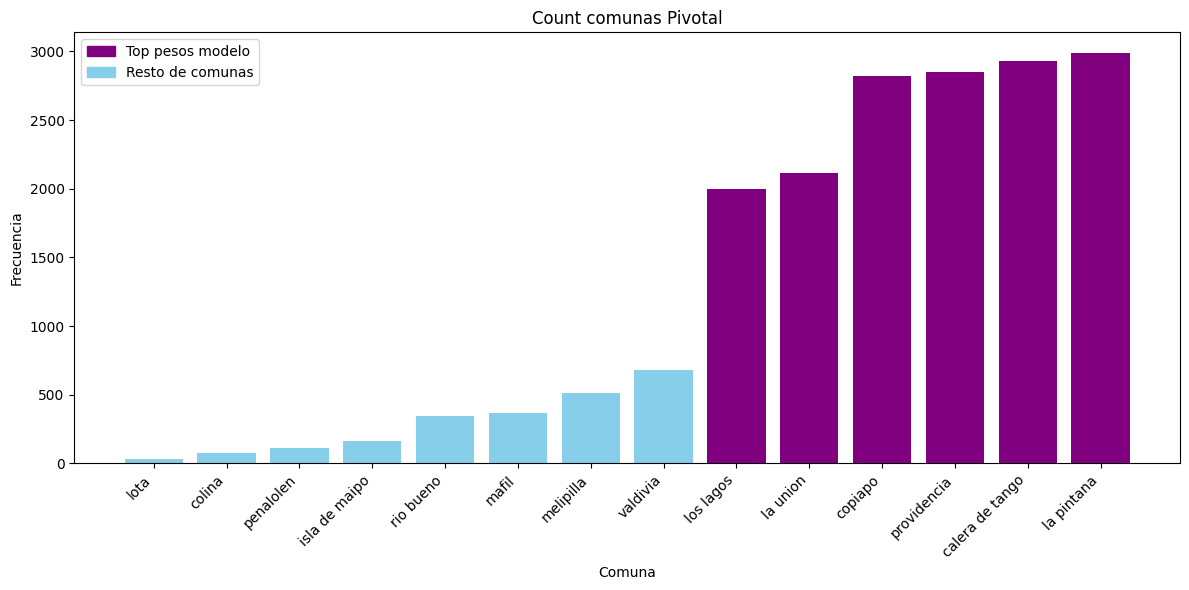

In [15]:
frecuencias_ordenadas_piv, conteo_piv, esperanza_empirica_piv = resultados_sampleo(modelo_con_limite, 28, 3000, "pivotal")

In [16]:
esperanza_empirica_piv

,Comuna,Esperanza Empírica,Peso Gurobi
0,lota,0.010333,0.009228
1,colina,0.024667,0.024169
2,penalolen,0.037000,0.037213
3,isla de maipo,0.054000,0.059105
4,rio bueno,0.116333,0.117569
5,mafil,0.123333,0.117569
6,melipilla,0.171667,0.172293
7,valdivia,0.227000,0.235139
8,los lagos,0.667333,0.647292
9,la union,0.704000,0.704188


# Sin Límite Regional

### Aquí se utiliza "s_new" puesto que al no considerar límites regionales, dos comunas vecinas que se intersectan efectivamente serán consideradas adyacentes, no como en el caso anterior.

In [17]:
with open('s_new.txt', 'r') as dict_file:
    dict_text1 = dict_file.read()
    dict_s1 = eval(dict_text1)

In [18]:
#modelo_sin_limite = modelo_sin_limite(0.0390625, R, 28, dict_s1, comunas)

In [19]:
#frecuencias_ordenadas_systematic_sl, conteo_systematic_sl, esperanza_empirica_systematic_sl = resultados_sampleo(modelo_sin_limite, 28, 5000, "systematic")

In [20]:
#frecuencias_ordenadas_piv_sl, conteo_piv_sl, esperanza_empirica_piv_sl = resultados_sampleo(modelo_sin_limite, 28, 5000, "pivotal")

In [21]:
#esperanza_empirica_systematic_sl

In [22]:
#esperanza_empirica_piv_sl

# Fase sampleo mapas

In [11]:
from sampleos import systematic_sampling, pivotal_sampling

In [12]:
from funciones import extraer_prob_centros

In [13]:
count_centros_fijados, centros_frac, top_centros_frac = extraer_prob_centros(modelo_con_limite, 28)

Hay 22 centros fijados por el Modelo

Hay 14 comunas con peso positivo



In [14]:
def centros_fijados(modelo):
    centros = []
    for v in modelo.getVars():
        if v.VarName.startswith("centros_j") and v.x == 1.0:
            texto_1 = v.VarName
            comuna = texto_1[texto_1.find('[')+1 : texto_1.find(']')]
            centros.append(comuna)
    return centros

In [15]:
centros_fijados = centros_fijados(modelo_con_limite)

In [22]:
t_mapas = 8000

In [17]:
comunas_t, probabilidades = zip(*centros_frac)
comunas_t = list(comunas_t)
probabilidades = list(probabilidades)

In [29]:
print(comunas_t)

['copiapo', 'la pintana', 'penalolen', 'providencia', 'colina', 'calera de tango', 'melipilla', 'isla de maipo', 'lota', 'valdivia', 'los lagos', 'mafil', 'la union', 'rio bueno']


In [27]:
from itertools import combinations
from tqdm import tqdm
import time

TIEMPO_MAX = 3 * 60 * 60   # 3 horas en segundos
t_inicio = time.time()

modelos_factibles = []
centros_factibles = []

centros_i_unicos = list(combinations(comunas_t, 6))
print(f"Total de combinaciones a evaluar: {len(centros_i_unicos)}")

for centros_i in tqdm(centros_i_unicos, desc="Buscando modelos factibles"):

    # chequeo de tiempo
    tiempo_transcurrido = time.time() - t_inicio
    if tiempo_transcurrido >= TIEMPO_MAX:
        print(" Límite de 3 horas alcanzado.")
        break

    centros_total_i = centros_fijados + list(centros_i)

    modelo_i = modelo_centros_fijos_con_limite(
        0.9, R, centros_total_i, dict_s, comunas, verbose=False
    )

    # almacenar solo si es factible
    if modelo_i:
        modelos_factibles.append(modelo_i)
        centros_factibles.append(centros_total_i)
        print(f'Factibles encontrados hasta ahora: {len(modelos_factibles)}')

tiempo_total = time.time() - t_inicio
horas = int(tiempo_total // 3600)
minutos = int((tiempo_total % 3600) // 60)
segundos = int(tiempo_total % 60)

print("Cantidad de modelos factibles encontrados:", len(modelos_factibles))
print(f"Tiempo total de ejecución: {horas}h {minutos}m {segundos}s")



Total de combinaciones a evaluar: 3003


Buscando modelos factibles:   0%|          | 0/3003 [00:00<?, ?it/s]

Set parameter LogToConsole to value 0
La cantidad de centros es 28


Buscando modelos factibles:   0%|          | 1/3003 [00:48<40:14:42, 48.26s/it]

El código se ejecutó en 48.23 segundos
Factibles encontrados hasta ahora: 1
Set parameter LogToConsole to value 0
La cantidad de centros es 28


...

El modelo es infactible
Set parameter LogToConsole to value 0
La cantidad de centros es 28


Buscando modelos factibles:   5%|▌         | 155/3003 [2:59:13<55:11:07, 69.76s/it]

El modelo es infactible
Set parameter LogToConsole to value 0
La cantidad de centros es 28


Buscando modelos factibles:   5%|▌         | 156/3003 [3:00:23<54:52:12, 69.38s/it]

El modelo es infactible
 Límite de 3 horas alcanzado.
Cantidad de modelos factibles encontrados: 84
Tiempo total de ejecución: 3h 0m 23s


In [23]:
from tqdm import tqdm

modelos_factibles = []
centros_factibles = []

centros_ya_probados = set() 

for mapa in tqdm(range(t_mapas), desc="Buscando modelos factibles"):

    centros_i = systematic_sampling(comunas_t, probabilidades, 6)

    centros_i_key = tuple(sorted(centros_i))

    # si ya se probó, saltar
    if centros_i_key in centros_ya_probados:
        continue

    centros_ya_probados.add(centros_i_key)

    centros_total_i = centros_fijados + centros_i

    modelo_i = modelo_centros_fijos_con_limite(
        0.95, R, centros_total_i, dict_s, comunas, verbose=False
    )

    # almacenar solo si es factible
    if modelo_i:
        modelos_factibles.append(modelo_i)
        centros_factibles.append(centros_total_i)

    print(f'Factibles encontrados hasta ahora: {len(modelos_factibles)}')

print("Cantidad de modelos factibles encontrados:", len(modelos_factibles))



Buscando modelos factibles:   0%|          | 0/8000 [00:00<?, ?it/s]

Set parameter LogToConsole to value 0
La cantidad de centros es 28


Buscando modelos factibles:   0%|          | 1/8000 [01:03<141:59:48, 63.91s/it]

El código se ejecutó en 63.88 segundos
Factibles encontrados hasta ahora: 1
Set parameter LogToConsole to value 0
La cantidad de centros es 28


Buscando modelos factibles:   0%|          | 2/8000 [01:59<130:43:26, 58.84s/it]

...

El código se ejecutó en 63.22 segundos
Factibles encontrados hasta ahora: 12
Set parameter LogToConsole to value 0
La cantidad de centros es 28


Buscando modelos factibles:  76%|███████▌  | 6083/8000 [10:41<00:30, 63.15it/s] 

El código se ejecutó en 36.72 segundos
Factibles encontrados hasta ahora: 13


Buscando modelos factibles: 100%|██████████| 8000/8000 [10:41<00:00, 12.46it/s]

Cantidad de modelos factibles encontrados: 13


In [124]:
modelos_factibles[0].printAttr("X")


    Variable            X 
-------------------------
x[arica,arica]            1 
x[camarones,arica]            1 
x[putre,arica]            1 
x[general lagos,arica]            1 
x[iquique,huara]            1 
x[alto hospicio,alto hospicio]            1 
x[pozo almonte,huara]            1 
x[camina,huara]            1 
x[colchane,huara]            1 
x[huara,huara]            1 
x[pica,huara]            1 
x[antofagasta,antofagasta]            1 
x[mejillones,antofagasta]            1 
x[sierra gorda,antofagasta]            1 
x[taltal,antofagasta]            1 
x[calama,antofagasta]            1 
x[ollague,antofagasta]            1 
x[san pedro de atacama,antofagasta]            1 
x[tocopilla,antofagasta]            1 
x[maria elena,antofagasta]            1 
x[copiapo,copiapo]            1 
x[caldera,copiapo]            1 
x[tierra amarilla,vallenar]            1 
x[chanaral,copiapo]            1 
x[diego de almagro,copiapo]            1 
x[vallenar,vallenar]            1 
x[alto

In [1]:
lista_centros = []
modelos = []
for mapa in range(t_mapas):
    centros_i = systematic_sampling(comunas_t, probabilidades, 6)
    centros_total_i = centros_fijados+centros_i
    lista_centros.append(centros_total_i)
    modelo_i = modelo_centros_fijos_con_limite(0.95, R, centros_total_i, dict_s, comunas)
    modelos.append(modelo_i)

NameError: name 't_mapas' is not defined

# Guardemos el resultado de estos modelos en un archivo

In [ ]:
modelos_infactibles = 0
for modelo in modelos:
    if modelo == False:
        modelos_infactibles += 1
print(modelos_infactibles)

0


In [ ]:
# ================== EXPORTAR DESDE RESULTADOS CACHEADOS (versión simple) ==================
import os, json, time
import pandas as pd

def exportar_desde_cache(
    lista_centros, modelos, salida_base,
    centros_fijados, R, comunas,
    C=None,
    comunas_t=None,
    probabilidades=None,
    metodo="Systematic",
    K_total=28, K_muestreados=6
):
    ensure_dir(salida_base)
    resumenes = []
    t0 = time.time()

    # y* (y_star) global, si tenemos comunas_t y probabilidades
    y_star_global = {}
    if comunas_t is not None and probabilidades is not None:
        assert len(comunas_t) == len(probabilidades), \
            f"len(comunas_t)={len(comunas_t)} != len(probabilidades)={len(probabilidades)}"
        y_star_global = {str(cm): float(p) for cm, p in zip(comunas_t, probabilidades)}

    for t, (centros_total_t, modelo_t) in enumerate(zip(lista_centros, modelos), start=1):
        etiqueta = f"t_{t:03d}"
        outdir = os.path.join(salida_base, etiqueta)
        ensure_dir(outdir)

        # reconstruir centros muestreados = total - fijos
        set_total = set(map(str, centros_total_t))
        set_fijos = set(map(str, centros_fijados))
        centros_muestreados_t = sorted(set_total - set_fijos, key=lambda x: x)

        # universo para y_t
        universo_C = list(C) if C is not None else list(R)
        y_t = {str(j): (1.0 if str(j) in set_total else 0.0) for j in universo_C}

        # metadatos muestreo
        meta_muestreo = {
            "metodo": metodo,
            "K_total": K_total,
            "K_fijos": len(centros_fijados),
            "K_muestreados": K_muestreados,
            "y_star": y_star_global,
            "y_t": y_t,
            "centros_fijos": list(map(str, centros_fijados)),
            "centros_muestreados": list(map(str, centros_muestreados_t)),
            "centros_total": list(map(str, centros_total_t)),
        }

        # exportar modelo (asumimos factible y óptimo SIEMPRE)
        resumen = extraer_y_guardar_modelo(
            model   = modelo_t,
            centros = centros_total_t,
            R       = R,
            comunas = comunas,
            outdir  = outdir,
            etiqueta= etiqueta,
            meta_muestreo = meta_muestreo,
        )

        resumenes.append(resumen)

    # archivos globales
    pd.DataFrame(resumenes).to_csv(os.path.join(salida_base, "resumen_modelos.csv"), index=False)
    with open(os.path.join(salida_base, "resumen_modelos.json"), "w", encoding="utf-8") as f:
        json.dump(resumenes, f, ensure_ascii=False, indent=2)
    with open(os.path.join(salida_base, "lista_centros_por_t.json"), "w", encoding="utf-8") as f:
        json.dump([list(map(str, ls)) for ls in lista_centros], f, ensure_ascii=False, indent=2)

    print(f"OK: {len(modelos)} modelos exportados | tiempo: {time.time()-t0:.2f}s | carpeta: {os.path.abspath(salida_base)}")
# ==========================================================================

# EJEMPLO DE USO:
# exportar_desde_cache(lista_centros, modelos, "resultados",
#                      centros_fijados, R, comunas,
#                      C=C,
#                      comunas_t=comunas_t,
#                      probabilidades=probabilidades,
#                      metodo="Systematic",
#                      K_total=28, K_muestreados=6)


In [ ]:
# === Ejecutar exportación desde los resultados ya calculados ===
# Requisitos previos en el entorno:
# - lista_centros   (list de listas)
# - modelos         (list de modelos Gurobi ya optimizados)
# - centros_fijados (list)
# - R, comunas      (tus estructuras actuales)
# - (opcional) C, comunas_t, probabilidades

salida_base = "resultados"  # carpeta donde guardar todo

exportar_desde_cache(
    lista_centros=lista_centros,
    modelos=modelos,
    salida_base=salida_base,
    centros_fijados=centros_fijados,
    R=R,
    comunas=comunas,
    # Opcionales (descomenta si los tienes):
    # C=C,
    # comunas_t=comunas_t,
    # probabilidades=probabilidades,
    metodo="Systematic",
    K_total=28,
    K_muestreados=6,
)


OK: 100 modelos exportados | tiempo: 142.00s | carpeta: c:\Users\andre\OneDrive - Universidad Católica de Chile\Magíster\Tesis\Códigos\resultados


In [ ]:
csv_path = os.path.join("resultados/t_001", "modelo_t_001_asignaciones.csv")
df_resumen = pd.read_csv(csv_path)

print("Resumen CSV:")
print(df_resumen.head())   # primeras filas

Resumen CSV:
       i              j    x
0  arica          arica  1.0
1  arica  alto hospicio  0.0
2  arica          huara  0.0
3  arica    antofagasta  0.0
4  arica       vallenar  0.0


In [ ]:
csv_path = os.path.join("resultados/t_001", "modelo_t_001_asignadas_1.csv")
df_resumen = pd.read_csv(csv_path)

print("Resumen CSV:")
print(df_resumen.head())   # primeras filas

Resumen CSV:
               i      j
0          arica  arica
1      camarones  arica
2          putre  arica
3  general lagos  arica
4        iquique  huara


In [ ]:
csv_path = os.path.join("resultados/t_001", "modelo_t_001_cargas_por_centro.csv")
df_resumen = pd.read_csv(csv_path)

print("Resumen CSV:")
print(df_resumen.head())   # primeras filas

Resumen CSV:
          centro  carga_poblacion
0          arica         226068.0
1  alto hospicio         108375.0
2          huara         222183.0
3    antofagasta         607534.0
4       vallenar          64257.0


In [ ]:
# === Leer el resumen en CSV ===
#csv_path = os.path.join(salida_base, "resumen_modelos.csv")
#df_resumen = pd.read_csv(csv_path)

#print("Resumen CSV:")
#print(df_resumen.head())   # primeras filas

# === Leer el resumen en JSON ===
json_path = os.path.join("resultados/t_001", "modelo_t_001_resumen.json")
with open(json_path, "r", encoding="utf-8") as f:
    resumen_json = json.load(f)

print(resumen_json)


Resumen JSON (primer item):
{'etiqueta': 't_001', 'status': 2, 'status_name': 'OPTIMAL', 'obj_val': 0.0, 'runtime': 0.059999942779541016, 'num_vars': 9688, 'num_constrs': 11075, 'centros': ['arica', 'alto hospicio', 'huara', 'antofagasta', 'vallenar', 'coquimbo', 'paiguano', 'valparaiso', 'villa alemana', 'santiago', 'lo espejo', 'penaflor', 'rancagua', 'yerbas buenas', 'chillan', 'contulmo', 'alto bio bio', 'victoria', 'futrono', 'osorno', 'rio ibanez', 'torres del paine', 'copiapo', 'la pintana', 'providencia', 'calera de tango', 'los lagos', 'la union'], 'archivos': {'lp': 'resultados\\t_001\\modelo_t_001.lp', 'sol': 'resultados\\t_001\\modelo_t_001.sol', 'iis': 'resultados\\t_001\\modelo_t_001.ilp', 'csv_asignaciones': 'resultados\\t_001\\modelo_t_001_asignaciones.csv', 'csv_asignadas_1': 'resultados\\t_001\\modelo_t_001_asignadas_1.csv', 'csv_cargas': 'resultados\\t_001\\modelo_t_001_cargas_por_centro.csv'}, 'muestreo': {'metodo': 'Systematic', 'K_total': 28, 'K_fijos': 22, 'K_mu

# estudiemos

In [ ]:
import os, json, pandas as pd, numpy as np
import matplotlib.pyplot as plt

BASE   = "resultados"   
N_RUNS = 100            
EPS    = 1e-12          # tolerancia numérica para >0

# Extraermos y* (centros_j) del pl relajado
y_star = {}
for v in modelo_con_limite.getVars():
    if v.VarName.startswith("centros_j["):
        j = v.VarName[v.VarName.find("[")+1 : v.VarName.find("]")]
        y_star[str(j)] = float(v.x)

# J+ = { j != "0" y y_j^* > 0 }
J_pos = {j for j, val in y_star.items() if j != "0" and val > EPS}
print(f"|J_pos| = {len(J_pos)}")


|J_pos| = 36


In [ ]:

# x* del relajado (fraccional) y también sus asignaciones binaria (ind>0)
x_star_frac = {}        # (i,j) -> valor fraccional > 0
x_star_bin  = set()     # {(i,j)} con valor > 0
for v in modelo_con_limite.getVars():
    if v.VarName.startswith("signaciones_ij["):  # <— prefijo correcto
        idx = v.VarName[v.VarName.find("[")+1 : v.VarName.find("]")].split(",")
        i, j = idx[0].strip(), idx[1].strip()
        if j in J_pos:                    # quedarnos solo con j en J+
            val = float(v.x)
            if val > EPS:
                x_star_frac[(i, j)] = val
                x_star_bin.add((i, j))

print("x_ij* > 0 (fraccional):", len(x_star_frac))
print("x_ij* > 0 (binario)   :", len(x_star_bin))
# Opcional: muestra algunos
print("Ejemplos x*_frac:", list(x_star_frac.items())[:5])


x_ij* > 0 (fraccional): 527
x_ij* > 0 (binario)   : 527
Ejemplos x*_frac: [(('arica', 'arica'), 1.0), (('camarones', 'arica'), 1.0), (('putre', 'arica'), 1.0), (('general lagos', 'arica'), 1.0), (('iquique', 'huara'), 1.0)]


In [ ]:
def listar_runs(base, prefijo="t_", ndigits=3, n=N_RUNS):
    paths = []
    for k in range(1, n+1):
        name = f"{prefijo}{k:0{ndigits}d}"
        path = os.path.join(base, name)
        if os.path.isdir(path):
            paths.append(path)
    if not paths:
        raise FileNotFoundError(f"No encontré subcarpetas t_*** dentro de {base}")
    return paths

def cargar_asignaciones(path_run):
    # Toma el *_asignaciones.csv "principal"
    cands = [f for f in os.listdir(path_run) if f.endswith("_asignaciones.csv")]
    if not cands:
        raise FileNotFoundError(f"No hallé *_asignaciones.csv en {path_run}")
    cands.sort()                 # por si hay varios, toma el primero
    df = pd.read_csv(os.path.join(path_run, cands[0]))
    # columnas esperadas: i, j, x
    assert {"i","j","x"}.issubset(df.columns), df.columns
    df["i"] = df["i"].astype(str)
    df["j"] = df["j"].astype(str)
    df["x"] = df["x"].astype(float)
    return df


In [ ]:

runs = listar_runs(BASE)

acum = {}   # (i,j) -> suma de x en runs
n_runs_validos = 0
for rdir in runs:
    df = cargar_asignaciones(rdir)
    df = df[df["j"].isin(J_pos)]         # filtrar por j en J+
    for t in df.itertuples(index=False):
        key = (t.i, t.j)
        acum[key] = acum.get(key, 0.0) + float(t.x)
    n_runs_validos += 1

E_x = {k: v / n_runs_validos for k, v in acum.items()}
print(f"Runs leídos: {n_runs_validos}")


Runs leídos: 100


In [ ]:

# armamos el dataframe con solo j\in J+ y j \neq 0) 
keys = set(E_x.keys()) | set(x_star_frac.keys()) | set(x_star_bin) # union de todos los pares (i,j)

rows = []
for (i,j) in sorted(keys):
    if j not in J_pos:          # seguridad extra
        continue
    e_val   = float(E_x.get((i,j), 0.0))
    x_frac  = x_star_frac.get((i,j), np.nan)
    x_bin   = 1.0 if (i,j) in x_star_bin else 0.0
    rows.append({
        "i": i,
        "j": j,
        "y_star_j": y_star.get(j, 0.0),
        "E[x_ij]": e_val,
        "x_ij_star_frac": x_frac,
        "x_ij_star_bin": x_bin,
        "E[x]-x*_frac": (e_val - x_frac) if not np.isnan(x_frac) else np.nan,
        "E[x]-x*_bin":  e_val - x_bin
    })

df_exp = pd.DataFrame(rows).sort_values(["j","i"]).reset_index(drop=True)
print("Preview:")
print(df_exp.head())


Preview:
                 i             j  y_star_j  E[x_ij]  x_ij_star_frac  \
0        algarrobo  alto bio bio       1.0      0.0             NaN   
1            alhue  alto bio bio       1.0      0.0             NaN   
2     alto bio bio  alto bio bio       1.0      1.0             1.0   
3  alto del carmen  alto bio bio       1.0      0.0             NaN   
4    alto hospicio  alto bio bio       1.0      0.0             NaN   

   x_ij_star_bin  E[x]-x*_frac  E[x]-x*_bin  
0            0.0           NaN          0.0  
1            0.0           NaN          0.0  
2            1.0           0.0          0.0  
3            0.0           NaN          0.0  
4            0.0           NaN          0.0  



- Si x_ij_star_frac = NaN es porque x_{ij}^* NO es mayor a 0
- Si E[x]-x*_frac = NaN es porque x_frac No existe

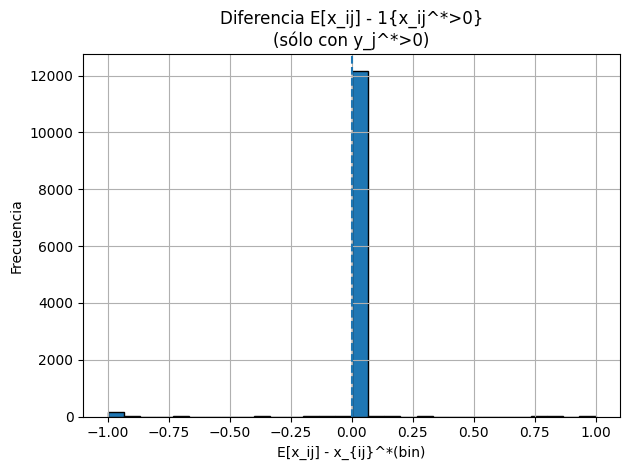

In [ ]:

# Histograma vs x*_bin
plt.hist(df_exp["E[x]-x*_bin"].values, bins=30, edgecolor="black")
plt.title("Diferencia E[x_ij] - 1{x_ij^*>0}\n(sólo con y_j^*>0)")
plt.xlabel("E[x_ij] - x_{ij}^*(bin)")
plt.ylabel("Frecuencia")
plt.axvline(0, linestyle="--")
plt.grid(True); plt.tight_layout(); plt.show()


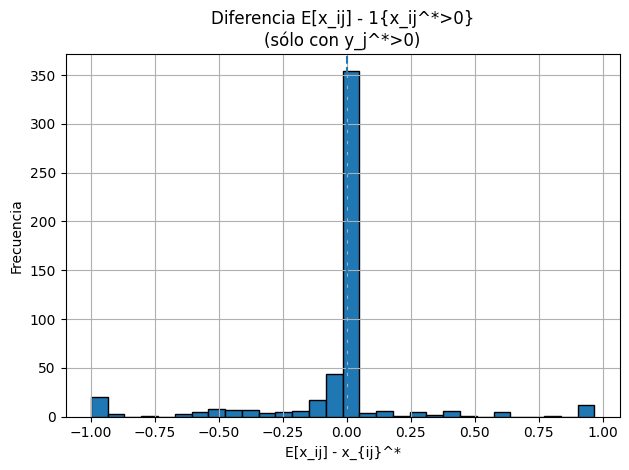

In [ ]:

# Histograma vs x*_frac
plt.hist(df_exp["E[x]-x*_frac"].values, bins=30, edgecolor="black")
plt.title("Diferencia E[x_ij] - 1{x_ij^*>0}\n(sólo con y_j^*>0)")
plt.xlabel("E[x_ij] - x_{ij}^*")
plt.ylabel("Frecuencia")
plt.axvline(0, linestyle="--")
plt.grid(True); plt.tight_layout(); plt.show()


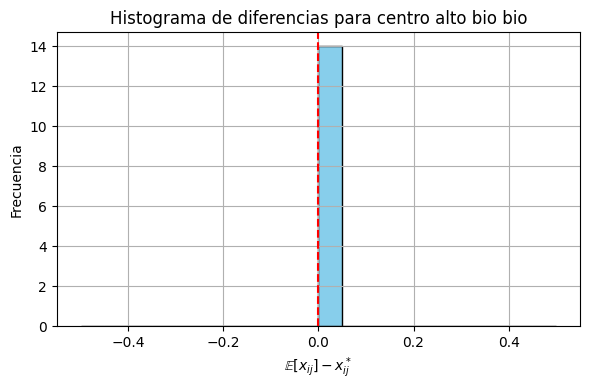

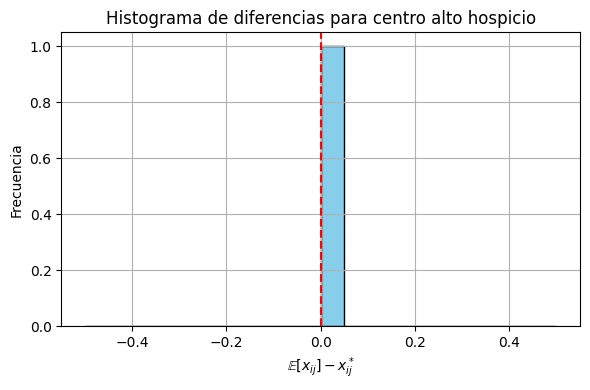

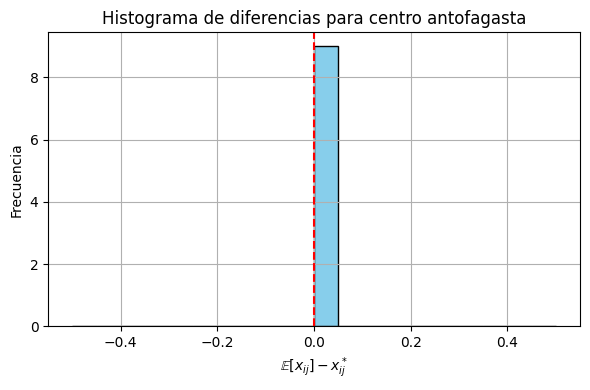

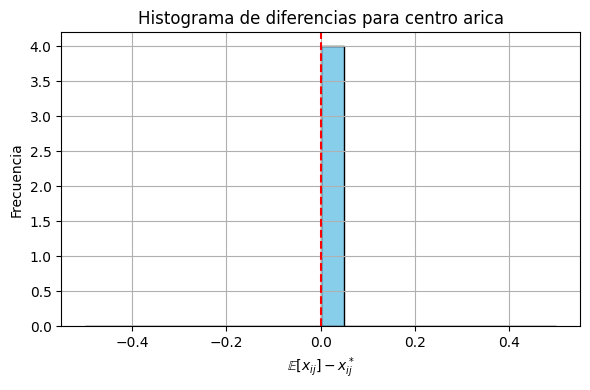

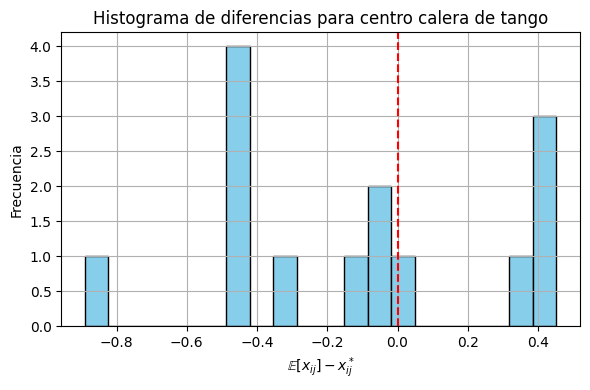

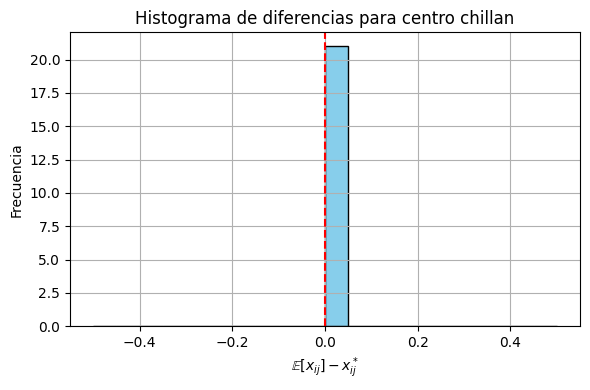

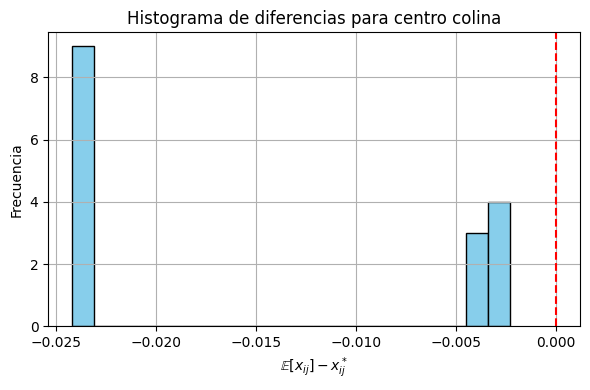

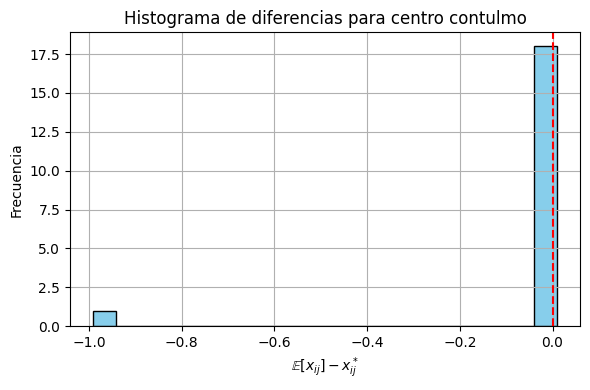

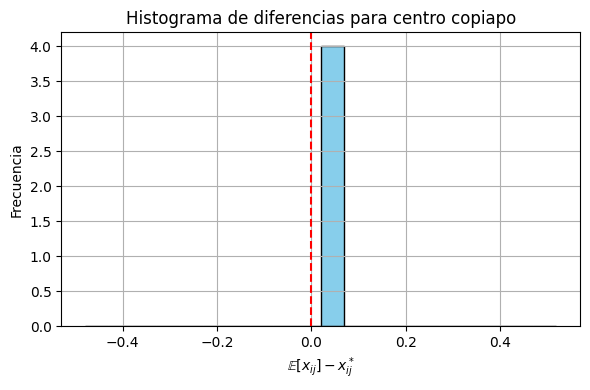

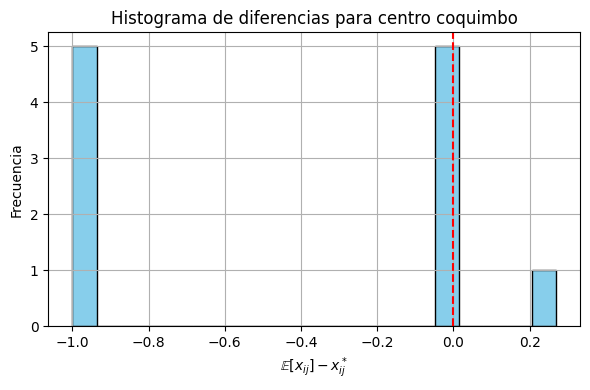

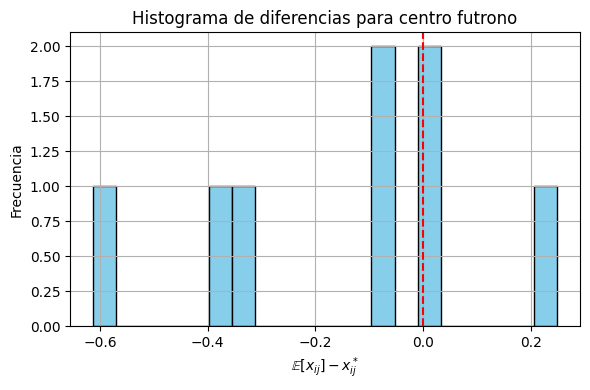

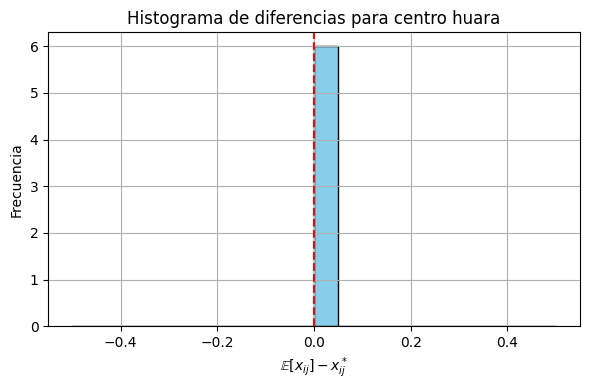

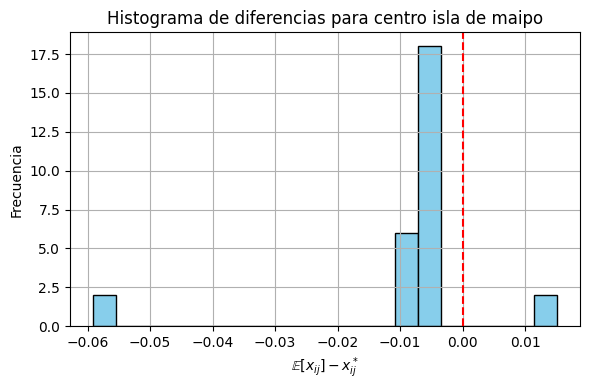

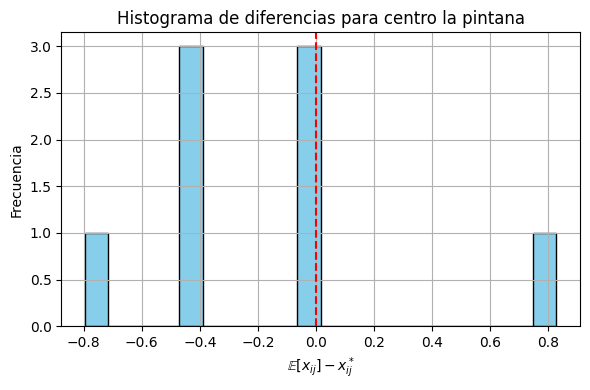

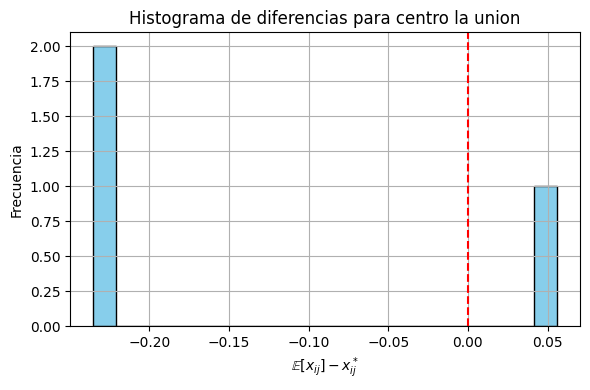

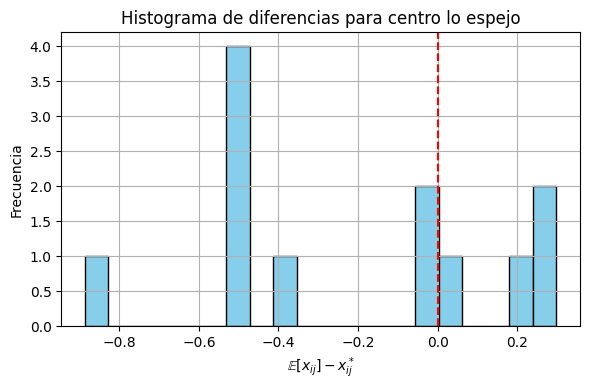

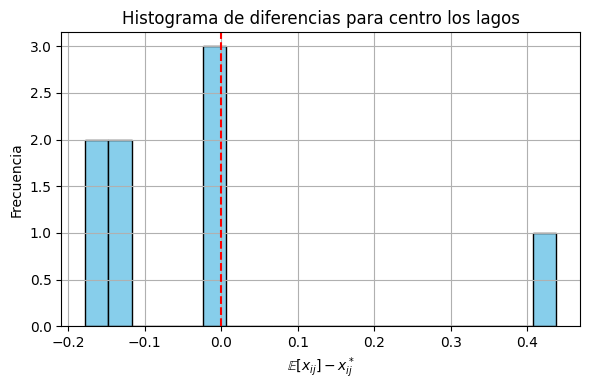

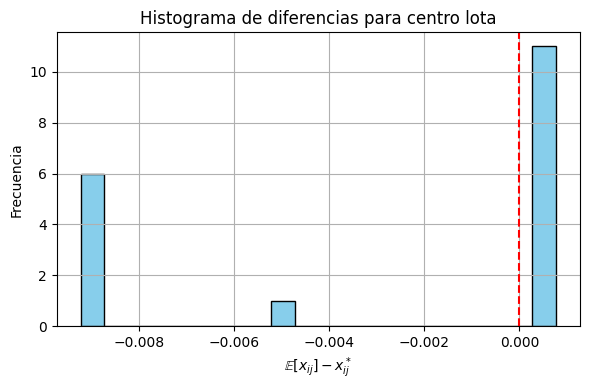

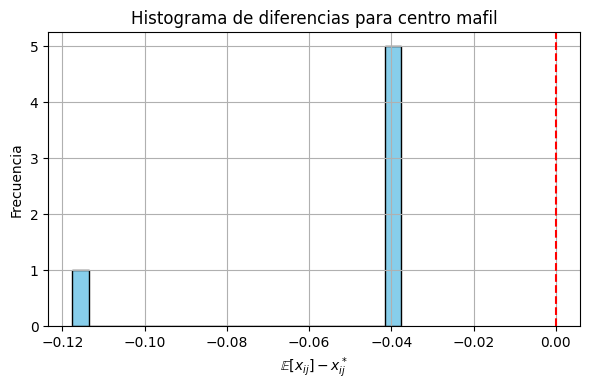

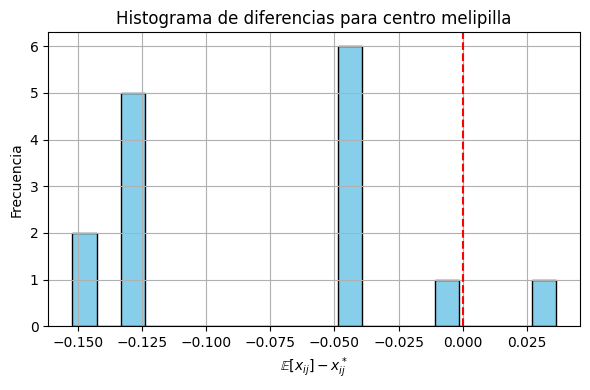

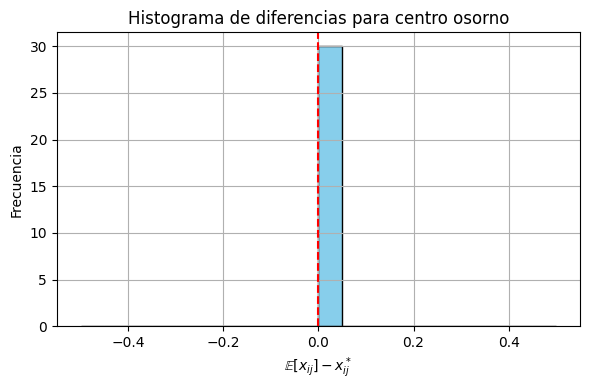

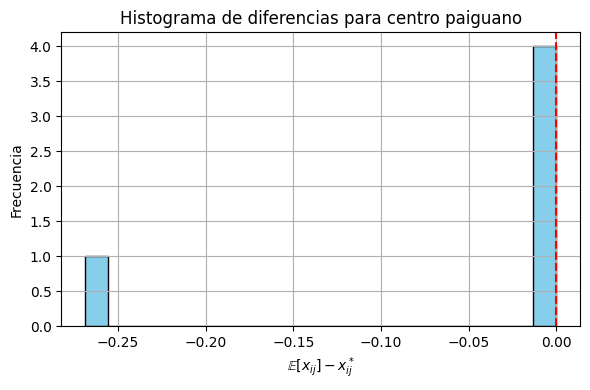

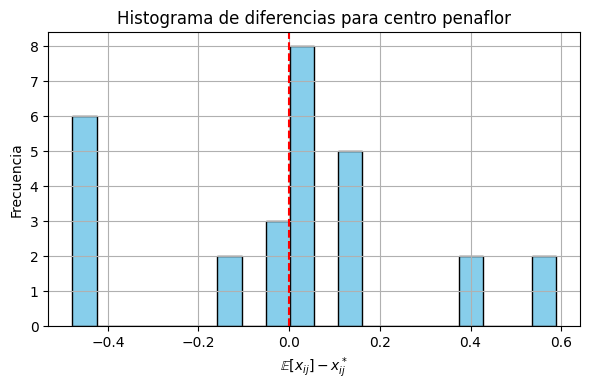

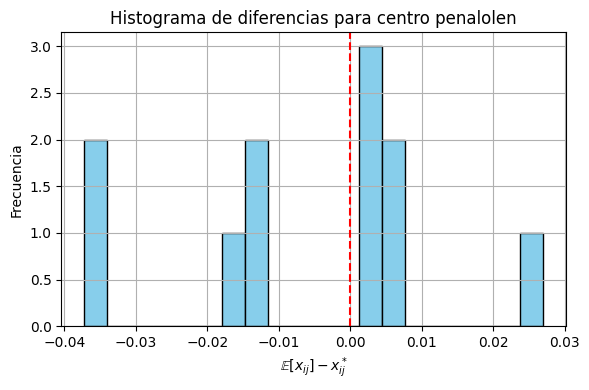

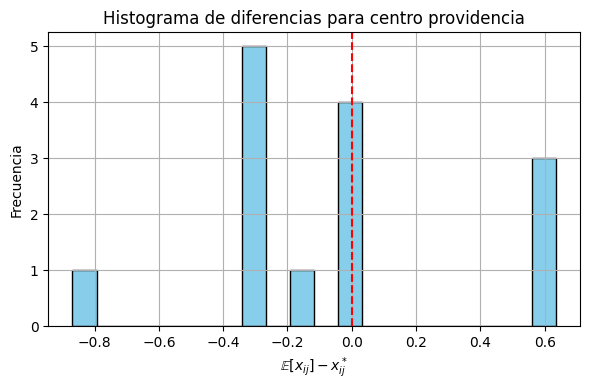

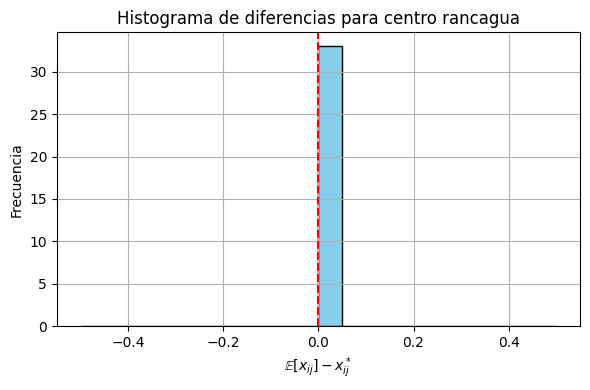

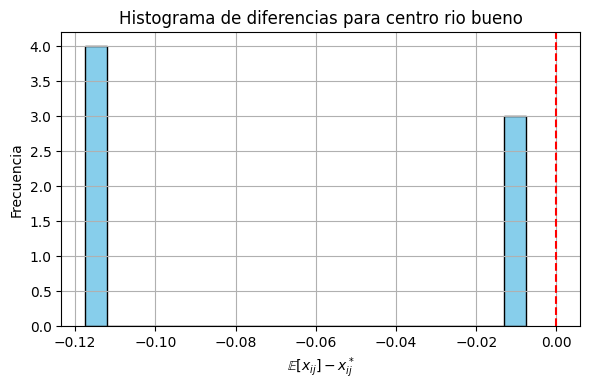

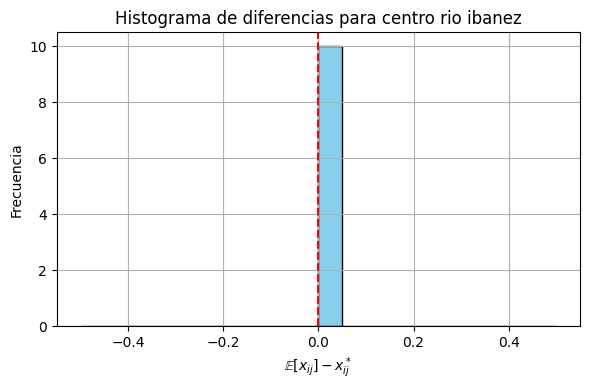

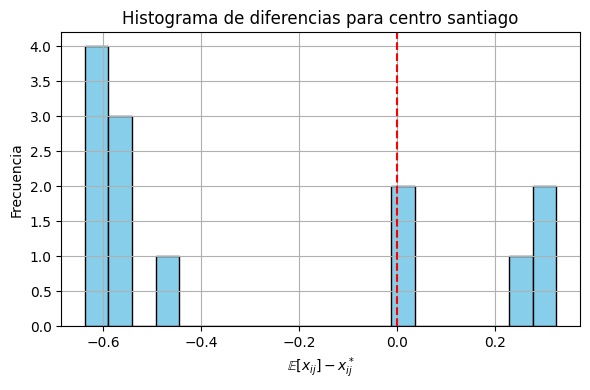

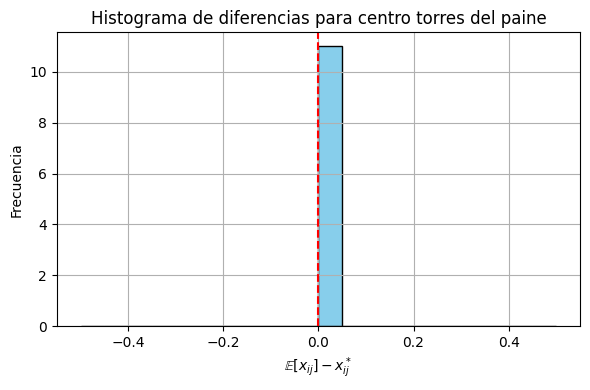

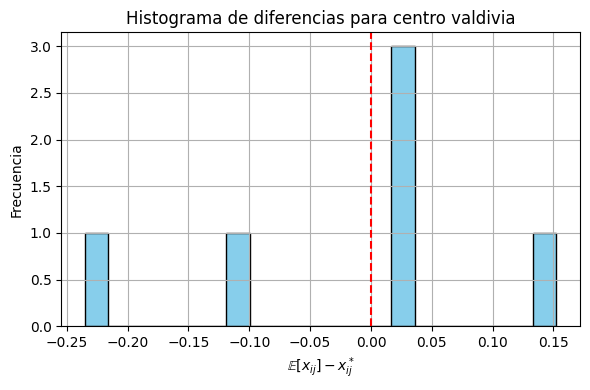

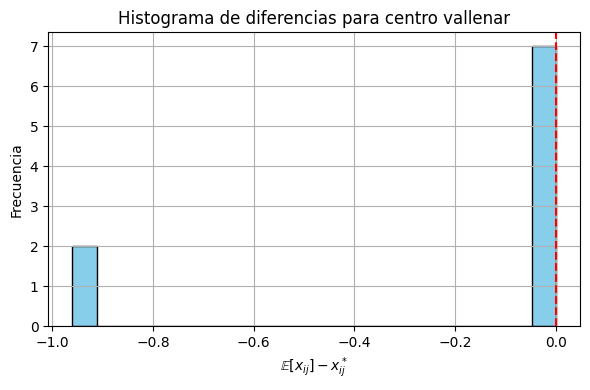

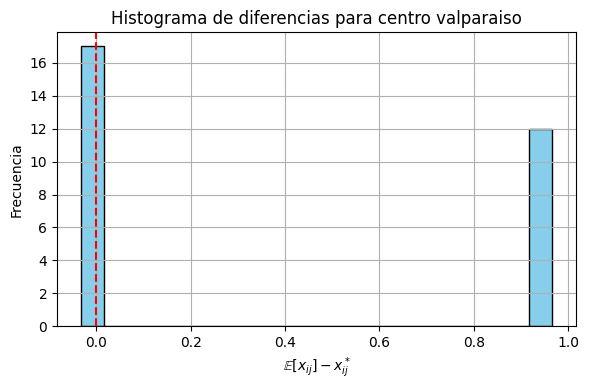

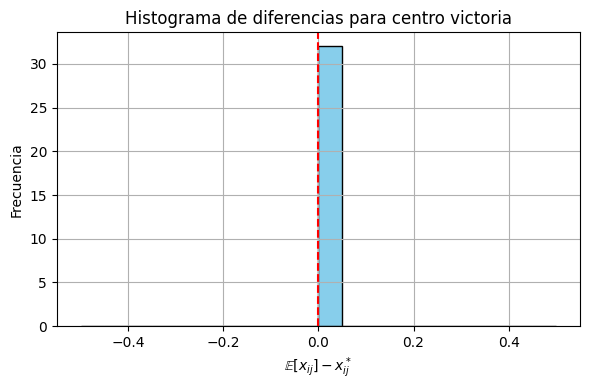

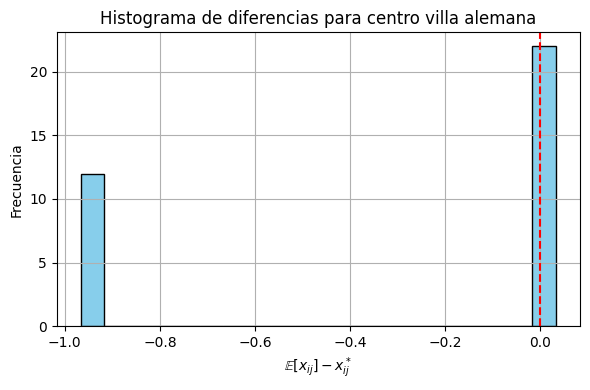

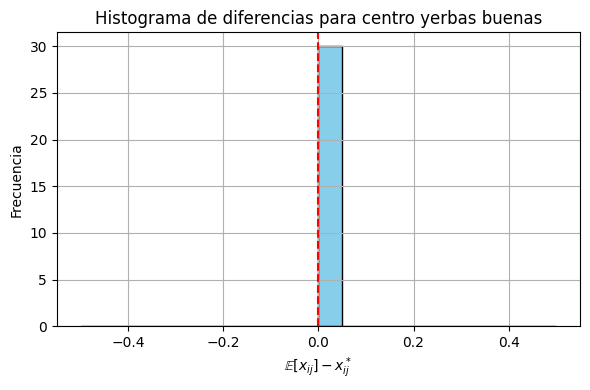

In [ ]:
for j, df_j in df_exp.groupby("j"):
    diffs = df_j["E[x]-x*_frac"].dropna().values

    plt.figure(figsize=(6,4))
    plt.hist(diffs, bins=20, edgecolor='black', color='skyblue')
    plt.title(f"Histograma de diferencias para centro {j}")
    plt.xlabel(r"$\mathbb{E}[x_{ij}] - x_{ij}^*$")
    plt.ylabel("Frecuencia")
    plt.axvline(0, color='red', linestyle='--')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import pandas as pd

df_exp = pd.read_csv("resultados/experimentos_agregado.csv")
tol = 1e-9  # tolerancia para comparar con 0 o 1

# Total de obs en el histograma (todas las filas consideradas)
N_total = len(df_exp)

# Conteos por categorías
n_cero   = int((df_exp["E[x]-x*_frac"].abs() <= tol).sum())           # diff ≈ 0
n_uno    = int((np.abs(df_exp["E[x]-x*_frac"] - 1.0) <= tol).sum())   # diff ≈ 1
n_neg    = int((df_exp["E[x]-x*_frac"] < -tol).sum())                 # diff < 0
n_pos    = int((df_exp["E[x]-x*_frac"] > tol).sum())                  # diff > 0
n_otro   = N_total - (n_cero + n_uno)                                # resto (entre 0 y 1, o cerca de ellos)

print("Total puntos graficados:", N_total)
print("≈0 :", n_cero)
print("≈1 :", n_uno)
print("<0 :", n_neg)
print(">0 :", n_pos)
print("otros:", n_otro)

# ¿Cuántos i por centro j? (asi explicamos los ejeY en cada histograma de j)
per_j = df_exp.groupby("j")["i"].nunique().sort_values(ascending=False)
print("\n#i por centro (min/mediana/max):", per_j.min(), per_j.median(), per_j.max())
print("Suma de #i sobre todos los j:", per_j.sum())  # debería ser N_total


Total puntos graficados: 12456
≈0 : 0
≈1 : 0
<0 : 0
>0 : 0
otros: 12456

#i por centro (min/mediana/max): 346 346.0 346
Suma de #i sobre todos los j: 12456


In [ ]:

# Si quieres también contra x*_frac (si existe)
if df_exp["E[x]-x*_frac"].notna().any():
    plt.hist(df_exp["E[x]-x*_frac"].dropna().values, bins=30, edgecolor="black")
    plt.title("Diferencia E[x_ij] - x_{ij}^*(fraccional)\n(sólo con y_j^*>0)")
    plt.xlabel("E[x_ij] - x_{ij}^*(frac)")
    plt.ylabel("Frecuencia")
    plt.axvline(0, linestyle="--")
    plt.grid(True); plt.tight_layout(); plt.show()


In [ ]:
print(df_exp["x_ij_star_frac"].notna().sum())
print(df_exp["E[x]-x*_frac"].notna().sum())


0
0


In [ ]:


out_all = os.path.join(BASE, "experimentos_agregado.csv")
df_exp.to_csv(out_all, index=False)
print(f"Guardado: {os.path.abspath(out_all)}")


Guardado: c:\Users\andre\OneDrive - Universidad Católica de Chile\Magíster\Tesis\Códigos\resultados\experimentos_agregado.csv


Cada fila de `experimentos_agregado.csv` contiene:

- **i** → la comuna (origen de la asignación).  
- **j** → el centro candidato.  
- **y_star_j** → el valor de $y_j^*$ del PL relajado.  
- **E[x_ij]** → la esperanza empírica de asignación, calculada promediando sobre todos los runs (las 100 carpetas `t_***`).  
- **x_ij_star_frac** → el valor fraccional $x_{ij}^*$ del PL relajado (si $>0$, el valor numérico; si no, `NaN`).  
- **x_ij_star_bin** → la versión binaria de $x_{ij}^*$: `1` si el relajado dio $x_{ij}^*>0$, `0` en caso contrario.  
- **E[x]-x*_frac** → la diferencia $\mathbb{E}[x_{ij}] - x_{ij}^*$ usando el valor fraccional (cuando existe).  
- **E[x]-x*_bin** → la diferencia $\mathbb{E}[x_{ij}] - 1\{x_{ij}^*>0\}$ usando la versión binaria.  


In [ ]:
EPS = 1e-12 

print("Total pares con x*_bin=1:", len(x_star_bin))
print("Total pares con E[x]>0:", sum(v>0 for v in E_x.values()))

negativos = []
for (i,j) in x_star_bin:
    e = float(E_x.get((i,j), 0.0))
    if e < 1 - 1e-9:   # margen numérico
        negativos.append(((i,j), e, 1.0, e-1.0))

print("Cantidad de difs negativas esperadas:", len(negativos))
if negativos[:5]:
    print("Ejemplos de negativos:", negativos[:5]) 


Total pares con x*_bin=1: 527
Total pares con E[x]>0: 476
Cantidad de difs negativas esperadas: 261
Ejemplos de negativos: [(('isla de maipo', 'penaflor'), 0.91, 1.0, -0.08999999999999997), (('la serena', 'paiguano'), 0.0, 1.0, -1.0), (('talagante', 'penaflor'), 0.91, 1.0, -0.08999999999999997), (('cerrillos', 'isla de maipo'), 0.0, 1.0, -1.0), (('macul', 'isla de maipo'), 0.0, 1.0, -1.0)]


In [ ]:
# ¿cuántos y_j* pequeños estás descartando?
cerca_cero = [(j, y_star[j]) for j in y_star if 0 < y_star[j] < 1e-6]
print("y_j* en (0,1e-6):", len(cerca_cero))

# ¿cuántos x_ij* > 0 sin EPS?
raw_pos = []
for v in modelo_con_limite.getVars():
    if v.VarName.startswith("asignaciones_ij["):
        i,j = v.VarName[v.VarName.find("[")+1 : v.VarName.find("]")].split(",")
        if float(v.x) > 0 and j.strip() != "0":
            raw_pos.append((i.strip(), j.strip()))
print("x_ij* > 0 sin EPS:", len(raw_pos))

y_j* en (0,1e-6): 0
x_ij* > 0 sin EPS: 0


                i             j  E[x_ij]  maps_de_100  porcentaje
             lebu      contulmo      1.0          100       100.0
quinta de tilcoco      rancagua      1.0          100       100.0
            rengo      rancagua      1.0          100       100.0
         requinoa      rancagua      1.0          100       100.0
       san carlos       chillan      1.0          100       100.0
          tucapel  alto bio bio      1.0          100       100.0
     san fernando      rancagua      1.0          100       100.0
      san vicente      rancagua      1.0          100       100.0
        vichuquen yerbas buenas      1.0          100       100.0
       santa cruz      rancagua      1.0          100       100.0
       san fabian       chillan      1.0          100       100.0
            aysen    rio ibanez      1.0          100       100.0
     villa alegre yerbas buenas      1.0          100       100.0
      chile chico    rio ibanez      1.0          100       100.0
          

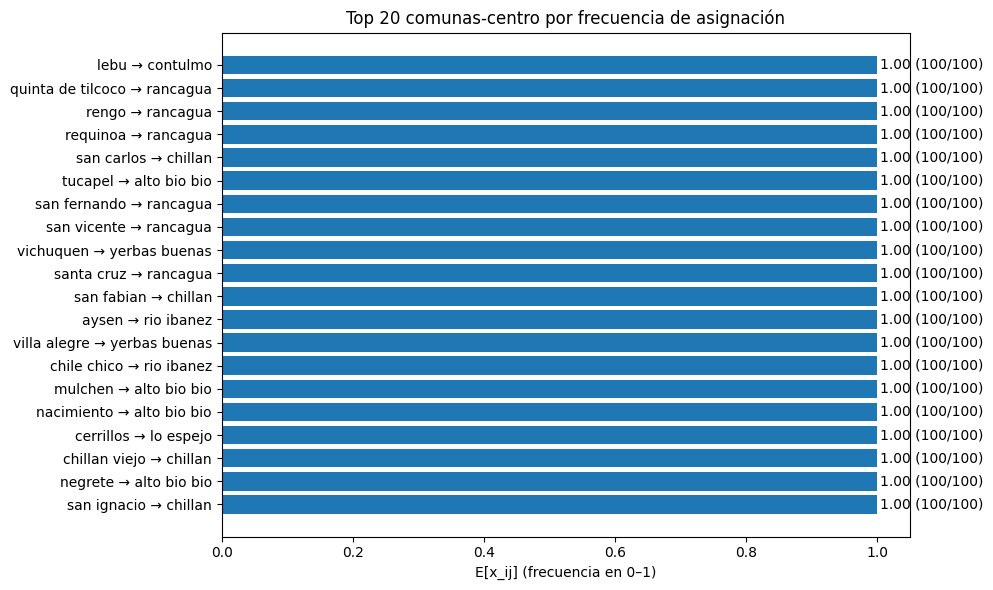

In [ ]:
df = pd.read_csv("resultados/experimentos_agregado.csv")

# excluir autoasignaciones
df_noauto = df[df["i"] != df["j"]].copy()

# top 20 por esperanza
top20 = (
    df_noauto[["i","j","E[x_ij]"]]
    .sort_values("E[x_ij]", ascending=False)
    .head(20)
    .copy()
)

top20["maps_de_100"] = (top20["E[x_ij]"]*100).round().astype(int)
top20["porcentaje"]  = (top20["E[x_ij]"]*100).round(1)

print(top20.to_string(index=False))

plt.figure(figsize=(10,6))
labels = [f"{row.i} → {row.j}" for row in top20.itertuples(index=False)]
plt.barh(labels, top20["E[x_ij]"])
plt.gca().invert_yaxis()
plt.xlabel("E[x_ij] (frecuencia en 0–1)")
plt.title("Top 20 comunas-centro por frecuencia de asignación")
for y, val in enumerate(top20["E[x_ij]"]):
    plt.text(val + 0.005, y, f"{val:.2f} ({int(round(val*100))}/100)", va="center")
plt.tight_layout()
plt.show()


In [ ]:
def top20_por_centro(g):
    g = g.sort_values("E[x_ij]", ascending=False).head(20).copy()
    g["maps_de_100"] = (g["E[x_ij]"]*100).round().astype(int)
    g["porcentaje"]  = (g["E[x_ij]"]*100).round(1)
    return g[["i","j","E[x_ij]","maps_de_100","porcentaje"]]

res = df.groupby("j", group_keys=True).apply(top20_por_centro)

for j, sub in res.groupby(level=0):
    print(f"\n=== Centro: {j} ===")
    print(sub.droplevel(0).to_string(index=False))


=== Centro: alto bio bio ===
              i            j  E[x_ij]  maps_de_100  porcentaje
        florida alto bio bio      1.0          100       100.0
         antuco alto bio bio      1.0          100       100.0
   alto bio bio alto bio bio      1.0          100       100.0
    los angeles alto bio bio      1.0          100       100.0
           laja alto bio bio      1.0          100       100.0
        mulchen alto bio bio      1.0          100       100.0
     nacimiento alto bio bio      1.0          100       100.0
        negrete alto bio bio      1.0          100       100.0
        quilaco alto bio bio      1.0          100       100.0
       quilleco alto bio bio      1.0          100       100.0
    san rosendo alto bio bio      1.0          100       100.0
  santa barbara alto bio bio      1.0          100       100.0
         yumbel alto bio bio      1.0          100       100.0
        tucapel alto bio bio      1.0          100       100.0
        cabrero alto bio 

C:\Users\andre\AppData\Local\Temp\ipykernel_22392\3025588438.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  res = df.groupby("j", group_keys=True).apply(top20_por_centro)


In [ ]:
j_obj = "penaflor"
sub = df[df["j"] == j_obj].sort_values("E[x_ij]", ascending=False).head(20).copy()
sub["maps_de_100"] = (sub["E[x_ij]"]*100).round().astype(int)
sub["porcentaje"]  = (sub["E[x_ij]"]*100).round(1)
print(sub[["i","j","E[x_ij]","maps_de_100","porcentaje"]].to_string(index=False))

            i        j  E[x_ij]  maps_de_100  porcentaje
     penaflor penaflor     1.00          100       100.0
    talagante penaflor     0.91           91        91.0
        paine penaflor     0.91           91        91.0
     el monte penaflor     0.91           91        91.0
isla de maipo penaflor     0.91           91        91.0
         buin penaflor     0.91           91        91.0
padre hurtado penaflor     0.87           87        87.0
     curacavi penaflor     0.87           87        87.0
  maria pinto penaflor     0.87           87        87.0
        maipu penaflor     0.87           87        87.0
    san pedro penaflor     0.82           82        82.0
    melipilla penaflor     0.82           82        82.0
        alhue penaflor     0.82           82        82.0
        lampa penaflor     0.05            5         5.0
     pudahuel penaflor     0.05            5         5.0
       tiltil penaflor     0.05            5         5.0
    el bosque penaflor     0.02

# Veamos convergencia de los métodos

In [ ]:
def evaluar_convergencia(modelo, k, metodo='systematic', epsilon=0.015, N_max=1000):
    """
    Evalúa la evolución de la diferencia máxima entre la esperanza empírica y los pesos Gurobi
    a lo largo de N_max sampleos.

    Returns:
        historia_diferencias: lista con el error máximo en cada iteración.
    """
    print(f"\nEvaluando convergencia para {metodo} con tolerancia ε = {epsilon}")

    _, centros_frac, _ = extraer_prob_centros(modelo, k)
    comunas, probabilidades = zip(*centros_frac)
    comunas = list(comunas)
    probabilidades = list(probabilidades)

    conteo = {comuna: 0 for comuna in comunas}
    historia_diferencias = []
    convergencia_alcanzada = False
    n_convergencia = None

    for n in range(1, N_max + 1):
        # Sampleo
        if metodo == 'systematic':
            seleccionados = systematic_sampling(comunas, probabilidades, k)
        elif metodo == 'pivotal':
            seleccionados = pivotal_sampling(comunas, probabilidades)
        else:
            raise ValueError("Método no reconocido.")

        for comuna in seleccionados:
            conteo[comuna] += 1

        diferencias = []
        for i, comuna in enumerate(comunas):
            esperanza = conteo[comuna] / n
            peso = probabilidades[i]
            diferencia = abs(esperanza - peso)
            diferencias.append(diferencia)

        max_dif = max(diferencias)
        historia_diferencias.append(max_dif)

        # Registrar el primer n donde se alcanza la tolerancia
        if not convergencia_alcanzada and all(d <= epsilon for d in diferencias):
            n_convergencia = n
            convergencia_alcanzada = True
            print(f"Convergencia alcanzada en n = {n}")

    if not convergencia_alcanzada:
        print("No se alcanzó la convergencia en", N_max, "sampleos.")

    return historia_diferencias, n_convergencia

       

In [ ]:
errores_s, n_s = evaluar_convergencia(modelo_con_limite, k=28, metodo='systematic')
errores_p, n_p = evaluar_convergencia(modelo_con_limite, k=28, metodo='pivotal')

print(f"Systematic alcanzó convergencia en: {n_s} sampleos")
print(f"Pivotal alcanzó convergencia en: {n_p} sampleos")




Evaluando convergencia para systematic con tolerancia ε = 0.015
Hay 22 centros fijados por el Modelo

Hay 14 comunas con peso positivo

Convergencia alcanzada en n = 589

Evaluando convergencia para pivotal con tolerancia ε = 0.015
Hay 22 centros fijados por el Modelo

Hay 14 comunas con peso positivo

No se alcanzó la convergencia en 1000 sampleos.
Systematic alcanzó convergencia en: 589 sampleos
Pivotal alcanzó convergencia en: None sampleos


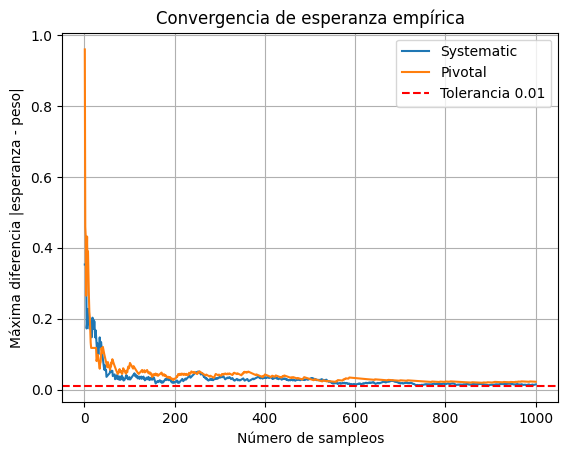

In [ ]:
plt.plot(range(1, len(errores_s)+1), errores_s, label="Systematic")
plt.plot(range(1, len(errores_p)+1), errores_p, label="Pivotal")
plt.axhline(0.01, color='red', linestyle='--', label=f"Tolerancia {0.01}")
plt.xlabel("Número de sampleos")
plt.ylabel("Máxima diferencia |esperanza - peso|")
plt.title("Convergencia de esperanza empírica")
plt.legend()
plt.grid(True)
plt.show()


# Tras diversas pruebas el mejor es Systematic

# Garantías

In [53]:
def build_matrices_from_gurobi(model, include_bounds=True, core_C_only=True,
                               core_prefixes=('assign[', 'center[', 'centers_total')):
    """
    Extrae matrices del modelo Gurobi y construye:
      - A_leq x <= b_leq  (todas las desigualdades normalizadas a '<=' + bounds opcionales)
      - C x = d           (todas las igualdades, o solo el 'núcleo' si core_C_only=True)

    Parámetros
    ----------
    include_bounds : bool
        Si True, añade límites de variables (LB/UB) como filas en A_leq.
    core_C_only : bool
        Si True, C incluye solo igualdades con nombres que empiezan en core_prefixes.
        Si False, C incluye todas las igualdades del modelo.
    core_prefixes : tuple[str]
        Prefijos para seleccionar el 'núcleo' de C cuando core_C_only=True.

    Retorna
    -------
    A_leq : sp.csr_matrix 
    b_leq : np.ndarray    
    C     : sp.csr_matrix 
    d     : np.ndarray   
    meta  : dict          (metadatos útiles)
    """
    import numpy as np
    import scipy.sparse as sp
    from gurobipy import GRB

    vars_   = model.getVars()
    constrs = model.getConstrs()

    var_names = [v.VarName for v in vars_]
    cnames    = model.getAttr(GRB.Attr.ConstrName, constrs)
    sense     = model.getAttr(GRB.Attr.Sense, constrs)   # '=', '<', '>', 'R'
    rhs       = np.array(model.getAttr(GRB.Attr.RHS, constrs), dtype=float)

    # Rangos si existen
    try:
        ranges = np.array(model.getAttr(GRB.Attr.Range, constrs), dtype=float)
    except Exception:
        ranges = np.zeros_like(rhs)

    A_all = model.getA().tocsr()
    m_all, n = A_all.shape

    # Clasificación por tipo
    idx_E = [i for i, s in enumerate(sense) if s == '=']
    idx_L = [i for i, s in enumerate(sense) if s in ('<', 'L')]
    idx_G = [i for i, s in enumerate(sense) if s in ('>', 'G')]
    idx_R = [i for i, s in enumerate(sense) if s == 'R']

    # ======================
    #  C x = d
    # ======================
    if idx_E:
        C_all = A_all[idx_E, :].tocsr()
        d_all = rhs[idx_E].copy()
        if core_C_only:
            keep = [r for r, k in enumerate(idx_E)
                    if cnames[idx_E[r]] and any(str(cnames[idx_E[r]]).startswith(p) for p in core_prefixes)]
            C = C_all[keep, :].tocsr() if keep else sp.csr_matrix((0, n))
            d = d_all[keep] if keep else np.zeros((0,), dtype=float)
            kept_eq_global_idx = [idx_E[r] for r in keep]
        else:
            C = C_all
            d = d_all
            kept_eq_global_idx = idx_E[:]
    else:
        C = sp.csr_matrix((0, n))
        d = np.zeros((0,), dtype=float)
        kept_eq_global_idx = []

    # ======================
    #  A_leq x <= b_leq
    # ======================
    blocks, b_parts = [], []

    if idx_L:
        blocks.append(A_all[idx_L, :])
        b_parts.append(rhs[idx_L])
    if idx_G:
        blocks.append(-A_all[idx_G, :])
        b_parts.append(-rhs[idx_G])
    if idx_R:
        blocks.append(A_all[idx_R, :])
        b_parts.append(rhs[idx_R])
        blocks.append(-A_all[idx_R, :])
        b_parts.append(-(rhs[idx_R] - ranges[idx_R]))

    A_leq = sp.vstack(blocks, format='csr') if blocks else sp.csr_matrix((0, n))
    b_leq = np.concatenate(b_parts) if b_parts else np.zeros((0,), dtype=float)

    # --- incluir bounds ---
    bound_row_start = A_leq.shape[0]
    added_bound_rows = 0
    if include_bounds:
        bound_rows, bound_rhs = [], []
        INF = 1e100
        for j, v in enumerate(vars_):
            if v.LB is not None and v.LB > -INF:
                bound_rows.append(sp.csr_matrix(([-1.0], ([0], [j])), shape=(1, n)))
                bound_rhs.append(-float(v.LB))
            if v.UB is not None and v.UB < INF:
                bound_rows.append(sp.csr_matrix(([1.0], ([0], [j])), shape=(1, n)))
                bound_rhs.append(float(v.UB))
        if bound_rows:
            B = sp.vstack(bound_rows, format='csr')
            A_leq = sp.vstack([A_leq, B], format='csr')
            b_leq = np.concatenate([b_leq, np.array(bound_rhs, dtype=float)])
            added_bound_rows = B.shape[0]

    # --- mapeo fila original -> A_leq ---
    row_map_leq = [None] * m_all
    pos = 0
    for k in range(m_all):
        if sense[k] in ('<', 'L'):
            row_map_leq[k] = pos; pos += 1
    for k in range(m_all):
        if sense[k] in ('>', 'G'):
            row_map_leq[k] = pos; pos += 1
    for k in range(m_all):
        if sense[k] == 'R':
            row_map_leq[k] = (pos, pos + 1); pos += 2

    # --- meta ---
    meta = dict(
        var_names=var_names,
        constr_names=list(cnames),
        sense=list(sense),
        idx_E=idx_E, idx_L=idx_L, idx_G=idx_G, idx_R=idx_R,
        kept_eq_global_idx=kept_eq_global_idx,
        row_map_leq=row_map_leq,
        A_shape=A_all.shape, Aleq_shape=A_leq.shape, C_shape=C.shape,
        bounds_added=added_bound_rows,
        bounds_start=bound_row_start,
    )

    return A_leq, b_leq, C, d, meta


In [23]:
def delta_b_from_eps(model, b_leq_ref, epsilon_ref, epsilon_new, meta):
    """
    Construye Δb para cambiar el ε de referencia (epsilon_ref) a un nuevo ε (epsilon_new).

    En este modelo:
        pop_up[j]:  sum_i p_i * x[i,j] <= phat * (1+ε) * y[j]
        pop_lo[j]: -sum_i p_i * x[i,j] <= -phat * (1-ε) * y[j]

    Como trabajamos con A_leq x <= b_leq, las filas correspondientes a estas
    restricciones cambian solo en el término independiente (b_leq).

    Al cambiar ε:
        Δb_up_j = phat * (ε_new - ε_ref)
        Δb_lo_j = phat * (ε_new - ε_ref)

    Retorna:
        delta : np.ndarray
            Vector Δb del mismo tamaño que b_leq_ref.
    """
    import numpy as np

    cnames = meta["constr_names"]
    row_map_leq = meta["row_map_leq"]

    # 1) Detectar filas correspondientes a pop_up / pop_lo
    pop_rows = []
    for k, name in enumerate(cnames):
        if not name:
            continue
        if name.startswith("pop_up[") or name.startswith("pop_lo["):
            r = row_map_leq[k]
            if r is not None:
                pop_rows.append(r)

    delta = np.zeros_like(b_leq_ref, dtype=float)

    if not pop_rows:
        print("No se detectaron restricciones nombradas como pop_up[...] / pop_lo[...].")
        return delta

    # 2) Estimar phat desde el modelo de referencia
    pop_up_vals, pop_lo_vals = [], []
    for k, name in enumerate(cnames):
        if not name:
            continue
        r = row_map_leq[k]
        if r is None:
            continue
        if name.startswith("pop_up["):
            denom = 1.0 + float(epsilon_ref)
            if abs(denom) > 1e-12:
                pop_up_vals.append(float(b_leq_ref[r]) / denom)
        elif name.startswith("pop_lo["):
            denom = 1.0 - float(epsilon_ref)
            if abs(denom) > 1e-12:
                pop_lo_vals.append(-float(b_leq_ref[r]) / denom)

    cand = []
    if pop_up_vals:
        cand.append(np.median(pop_up_vals))
    if pop_lo_vals:
        cand.append(np.median(pop_lo_vals))
    phat_est = float(np.median(cand)) if cand else 0.0

    # 3) Calcular Δb
    delta_val = phat_est * (float(epsilon_new) - float(epsilon_ref))
    for r in pop_rows:
        delta[r] = delta_val

    return delta


In [54]:
def verify_matrices(model, A_leq, b_leq, C, d, meta, show_examples=5):
    print("== Shapes ==")
    print("A_all (original):", meta["A_shape"])
    print("A_leq (<=)      :", A_leq.shape, "   b_leq len:", len(b_leq))
    print("C (core?)       :", meta["C_shape"], "   d len:", len(d))  # coincide con C.shape
    print("\n== Tipos originales ==")
    print("Eq (=):", len(meta["idx_E"]), "  Leq(<):", len(meta["idx_L"]),
          "  Geq(>):", len(meta["idx_G"]), "  Range(R):", len(meta["idx_R"]))

    # Muestra cuántas igualdades del núcleo quedaron (cuando core_C_only=True)
    if meta.get("kept_eq_global_idx"):
        print("Eq en C_core:", len(meta["kept_eq_global_idx"]))
    else:
        print("Eq en C (todas):", C.shape[0])

    print("\n== Variables (muestras) ==")
    for nm in meta["var_names"][:show_examples]:
        print(nm)
    print("...")


In [14]:
def detect_population_rows(meta, b_leq):
    """Devuelve índices en A_leq de pop_up y pop_lo (sin nombres), usando el sentido original."""
    sense = meta["sense"]
    row_map_leq = meta["row_map_leq"]

    up_rows = []   # '<' originales -> quedan tal cual en A_leq
    lo_rows = []   # '>' originales -> quedaron negadas en A_leq (RHS negativo)

    for k, s in enumerate(sense):
        r = row_map_leq[k]
        if r is None: 
            continue
        if s in ('<','L'):
            up_rows.append(r)
        elif s in ('>','G'):
            # Filtrar: contigüidad tiene rhs≈0; las inferiores de población tienen b_leq[r] < 0
            if b_leq[r] < -1e-9:
                lo_rows.append(r)

    return sorted(up_rows), sorted(lo_rows)

def estimate_phat_eps(b_leq, up_rows, lo_rows):
    """
    Si u = mediana(b_up) = phat*(1+eps),  l = mediana(-b_lo) = phat*(1-eps),
    entonces phat = (u+l)/2,  eps = (u-l)/(u+l).
    """
    if not up_rows or not lo_rows:
        return 0.0, 0.0
    u = float(np.median(b_leq[up_rows]))
    l = float(np.median(-b_leq[lo_rows]))
    phat = 0.5*(u + l)
    eps  = (u - l) / max(u + l, 1e-12)
    return phat, eps


In [ ]:
#vars_mod_lim = modelo_con_limite.getVars()
#x1 = np.array([v.X for v in vars_mod_lim], dtype=float)

In [56]:


A_leq, b_leq, C, d, meta = build_matrices_from_gurobi(modelo_con_limite, include_bounds=True)



In [ ]:
#A_leq, b_leq, C, d, meta = build_matrices_from_gurobi(modelo_con_limite, include_bounds=True)


In [57]:

verify_matrices(modelo_con_limite, A_leq, b_leq, C, d, meta)

== Shapes ==
A_all (original): (256545, 120062)
A_leq (<=)      : (266606, 120062)    b_leq len: 266606
C (core?)       : (693, 120062)    d len: 693

== Tipos originales ==
Eq (=): 110001   Leq(<): 120062   Geq(>): 26482   Range(R): 0
Eq en C_core: 693

== Variables (muestras) ==
asignaciones_ij[arica,arica]
asignaciones_ij[arica,camarones]
asignaciones_ij[arica,putre]
asignaciones_ij[arica,general lagos]
asignaciones_ij[arica,iquique]
...


In [16]:
from matrepr import mprint


In [17]:
mprint(A_leq, title=None, indices=False)

┌                                                                            ┐
│ 2.214e+05                                              ...                 │
│            2.214e+05                                   ...                 │
│                       2.214e+05                        ...                 │
│                                  2.214e+05             ...                 │
│                                             2.214e+05  ...                 │
│     :          :          :          :          :      ...  :   :   :   :  │
│                                                        ...                 │
│                                                        ...  -1             │
│                                                        ...      -1         │
│                                                        ...          -1     │
│                                                        ...              -1 │
└                                                   

In [18]:
mprint(C, title=None, indices=False)

┌                                                                             ┐
│ 1  1  1  1  1  1  1  1  1  1  1  1  ...                                     │
│                                     ...                                     │
│                                     ...                                     │
│                                     ...                                     │
│                                     ...                                     │
│ :  :  :  :  :  :  :  :  :  :  :  :  ...  :  :  :  :  :  :  :  :  :  :  :  : │
│                                     ...                                     │
│                                     ...                                     │
│                                     ...                                     │
│                                     ...                                     │
│                                     ...  1  1  1  1  1  1  1  1  1  1  1  1 │
└                                       

Construimos $M=\binom{A}{C}$ y aplicamos QR: $$M^\top P=QR$$

Luego, las primeras $rank(M)$ columnas pivote de $M^\top$ (dadar por $P$) corresponden a filas l.i. de $M$.

In [26]:
import numpy as np
from scipy import sparse
from tqdm import tqdm 


def filas_independientes_sparse_gauss(A_leq, C, tol=1e-12, drop_tol=1e-14):
    
    # Ensamblar M en CSR
    M = sparse.vstack([A_leq, C]).tocsr()
    m, n = M.shape

    pivots = {}            # columna pivote -> fila CSR con pivote en esa col
    pivot_cols = []        # lista ordenada de columnas pivote
    independent_rows = []

    for i in tqdm(range(m), desc="Filas procesadas", unit="fila"):
        row = M.getrow(i).tocsr()

        done = False

        while True:
            nz = row.indices
            if len(nz) == 0:
                # Fila dependiente
                break

            j = nz[0]  # primer no-cero (col pivote candidata)

            if j in pivots:
                # Eliminar pivote existente
                p_row = pivots[j]

                # valor del pivote en la fila actual y en la fila base
                a = row[0, j]
                b = p_row[0, j]  # siempre 1 si normalizamos (más rápido)

                factor = a / b

                # row = row - factor * p_row
                row = row - factor * p_row

                # Eliminar valores demasiado pequeños para evitar densidad
                row.data[np.abs(row.data) < drop_tol] = 0.0
                row.eliminate_zeros()

            else:
                # Nuevo pivote → fila independiente
                val = row[0, j]
                if abs(val) < tol:
                    # Casi-cero → considerar fila dependiente
                    break

                # Normalizamos para que el pivote sea 1
                row = row / val

                pivots[j] = row
                pivot_cols.append(j)
                independent_rows.append(i)
                done = True
                break

        if done:
            continue

    return independent_rows


In [ ]:
ind_rows = filas_independientes_sparse_gauss(A_leq, C)
print("Filas independientes:", len(ind_rows))


Filas procesadas: 100%|██████████| 240470/240470 [05:16<00:00, 758.99fila/s] 

Filas independientes: 119716


In [ ]:

M = sparse.vstack([A_leq, C]).tocsr()

M_LI = M[ind_rows, :]

In [20]:
A_reduced = A_leq[ind_A, :]
C_reduced = C[ind_C, :]


In [23]:
print("Filas L.I. que provienen de A_leq:", len(ind_A))
print("Filas L.I. que provienen de C:", len(ind_C))

Filas L.I. que provienen de A_leq: 119716
Filas L.I. que provienen de C: 0


In [29]:
mprint(M_LI, title=None, indices=False)

┌                                                                              ┐
│ 2.214e+05                                                 ...                │
│            2.214e+05                                      ...                │
│                       2.214e+05                           ...                │
│                                  2.214e+05                ...                │
│                                             2.214e+05     ...                │
│     :          :          :          :          :      :  ...  :  :  :  :  : │
│                                                           ...                │
│                                                           ...                │
│                                                           ...                │
│                                                           ...                │
│                                                           ...                │
└                           

\begin{aligned}
    \max &\sum_{i}^n\delta_i\\
    s.t.\quad &Ax\leq b^{(2)}\\
    &Cx=d^{(2)}\\
    &x-x^{(1)}\geq \delta\\
    &x^{(1)}-x \geq \delta\\
    &\delta \geq 0
\end{aligned}
Notamos que las restricciones de $\delta$ son equivalentes a decir $\delta_i \leq |x_i^{(1)}-x_i| \implies \|\delta\|_1 \leq \|x^{(1)}-x\|_1$.



\begin{aligned}
    -\min &\sum_{i}^n\delta_i\\
    s.t.\quad &0\leq b^{(2)} -Ax\\
    &Cx-d^{(2)}=0\\
    &0\geq \delta - x+x^{(1)}\\
    &0 \geq \delta -x^{(1)}+x\\
    &0 \geq -\delta
\end{aligned}

Luego, para considerar holgura complementaria calculamos el lagangriano:

$$
\mathcal{L} = -\sum_{i}^n\delta_i +u^\top(Ax-b^{(2)})+v^{\top}(Cx-d^{(2)})+r^\top(\delta - x+x^{(1)})+s^\top(\delta -x^{(1)}+x) + t^\top(-\delta)
$$

donde $(u,r,s,t)\geq 0$ y $v$ libre.

Luego,

$$
\dfrac{\partial \mathcal{L}}{\partial x} =  A^\top u +C^\top v -r + s= 0
$$

y

$$
 \dfrac{\partial \mathcal{L}}{\partial \delta} = -\mathbf{1} + r + s - t = 0\implies  r + s - t = \mathbf{1}
$$

Así, nos queda

\begin{aligned}
    &Ax\leq b^{(2)}, \quad Cx=d^{(2)},\quad \delta - x+x^{(1)} \leq 0, \quad \delta -x^{(1)}+x \leq 0, \quad -\delta \leq 0,\\
    &u^\top( b^{(2)} -Ax)=0,\quad r^\top(\delta - x + x^{(1)})=0,\quad s^\top(\delta - x^{(1)} + x)=0, \quad t^\top(-\delta) = 0,\\
    &A^\top u +C^\top v -r + s= 0, \quad r + s - t = \mathbf{1}, \quad (u,r,s,t) \geq 0.
\end{aligned}



Notemos ahora que

\begin{aligned}
    \sum_i \delta_i &= (r+s-t)^\top\delta   = r^\top(x^{(1)}-x)+s^\top(x-x^{(1)})+t^\top\delta\\
    &= (r-s)^\top x^{(1)}-(r-s)^\top x +t^\top\delta\\
    &= (A^\top u + C^\top v)^\top x^{(1)}-(A^\top u +C^\top v)^\top x + t^\top \delta\\
    &= u^\top Ax^{(1)}+v^\top Cx^{(1)}-u^\top Ax - v^\top Cx+t^\top\delta\\
    &\leq u^\top b^{(1)}+v^\top d^{(1)}-u^\top b^{(2)}-v^\top d^{(2)}+t\delta\\
    &= u^\top(b^{(1)}-b^{(2)})
\end{aligned}

In [58]:
from gurobipy import Model, GRB
import numpy as np

def modelo_distancia(x1, A_leq, b_leq, C, d):
    """
    Resuelve el LP:
        min  -sum(delta)
        s.a. A_leq x <= b_leq
             C x = d
             delta - x + x1 <= 0
             delta - x1 + x <= 0
             -delta <= 0

    Extrae:
        x, delta, u, r, s, t, v  

    Nota:
    - u  = duales de A_leq x <= b_leq
    - r  = duales de delta - x + x1 <= 0
    - s  = duales de delta - x1 + x <= 0
    - t  = duales de -delta <= 0
    - v  = duales de C x = d
    """

    m_leq, n = A_leq.shape
    m_eq = C.shape[0]

    model = Model("distancia")
    model.Params.OutputFlag = 1
    model.Params.Method = 1   
    model.Params.BarHomogeneous = 1

    # Variables
    x = model.addMVar(n, lb=-GRB.INFINITY, name="x")
    delta = model.addMVar(n, lb=0.0, name="delta")

    # Objetivo: min -sum(delta)  <=>  max sum(delta)
    model.setObjective(-delta.sum(), GRB.MINIMIZE)

    # A_leq x <= b_leq
    if m_leq > 0:
        A_block = model.addConstr(A_leq @ x <= b_leq, name="A_block")

    # C x = d
    if m_eq > 0:
        C_block = model.addConstr(C @ x == d, name="C_block")

    # delta - x + x1 <= 0
    R_block = model.addConstr(delta - x + x1 <= 0, name="R_block")

    # delta - x1 + x <= 0
    S_block = model.addConstr(delta - x1 + x <= 0, name="S_block")

    # -delta <= 0
    T_block = model.addConstr(-delta <= 0, name="T_block")

    # Optimizar
    model.optimize()

    # Valores primales
    x_val = x.X
    delta_val = delta.X

    # Duales
    u = A_block.Pi if m_leq > 0 else np.zeros(0)
    v = C_block.Pi if m_eq > 0 else np.zeros(0)
    r = R_block.Pi
    s = S_block.Pi
    t = T_block.Pi

    return {
        "x": x_val,
        "delta": delta_val,
        "u": np.array(u, dtype=float),
        "v": np.array(v, dtype=float),
        "r": np.array(r, dtype=float),
        "s": np.array(s, dtype=float),
        "t": np.array(t, dtype=float),
        "model": model
    }


In [59]:
sol = modelo_distancia(x1, A_leq, b_leq, C, d)


Set parameter OutputFlag to value 1
Set parameter Method to value 1
Set parameter BarHomogeneous to value 1
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-1355U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
Method  1
BarHomogeneous  1

Optimize a model with 627485 rows, 240124 columns and 1372954 nonzeros
Model fingerprint: 0x2b438a77
Coefficient statistics:
  Matrix range     [1e+00, 1e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-03, 3e+01]
Presolve removed 626494 rows and 239674 columns
Presolve time: 0.15s
Presolved: 991 rows, 450 columns, 2456 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -2.0000000e+30   4.000000e+30   2.000000e+00      0s
     103    0.0000000e+00   0.000000e+00   0.000000e+00      0s

Solved in 103 iteration

In [60]:
norm_u_1 = np.sum(np.abs(sol["u"]))
print("||u||_1 =", norm_u_1) # antes

||u||_1 = 244933.5011650743


In [61]:
norm_u_inf = np.max(np.abs(sol["u"]))

print("||u||_inf =", norm_u_inf) # ahora

||u||_inf = 4.0


In [24]:
sum_y_star = sum(y_star.values())
print("sum_j y*_j =", sum_y_star)


sum_j y*_j = 28.0


In [62]:
from funciones import calcular_poblacion_total
p_total = calcular_poblacion_total(comunas, R)
p_bar = p_total / 28

print("p_total =", p_total)
print("p_bar =", p_bar)


p_total = 17518991.514
p_bar = 625678.2683571428


In [125]:
eps0 = 0.8398
eps1 = 0.86
delta_eps = abs(eps1 - eps0)

norm_b_1 = delta_eps * p_bar

print("||b(1) - b(2)||_1 =", norm_b_1)

||b(1) - b(2)||_1 = 12638.701020814282


$$\|x^{(1)}-x^{(2)}\|_1\leq \|u\|_\infty \cdot \|b^{(1)}-b^{(2)}\|_1$$

In [ ]:

cota = norm_u_inf * norm_b_1
print("Cota final =", cota/(346*346)) 

Cota final = 0.42228945239781757


In [15]:
import math

T = 100          # número de muestras
n = 346*346       # dimensión
delta = 0.05      # nivel de confianza global (95%)

eps = math.sqrt( (1/(2*T)) * math.log(2*n/delta) )

print("epsilon =", eps)
print("Cota promedio por coordenada de |X̄ - E[X̄]| =", eps)
print("Cota L1 total =", n*eps)
print("Cota L1 normalizada por 346*346 =", (n*eps)/(346*346)) 


epsilon = 0.27732433182313254
Cota promedio por coordenada de |X̄ - E[X̄]| = 0.27732433182313254
Cota L1 total = 33200.159708538136
Cota L1 normalizada por 346*346 = 0.27732433182313254


\begin{aligned}
    \dfrac{1}{n}\|\bar{X}-X^*\|_1 &\leq \dfrac{1}{n}\|\bar{X}-\mathbb{E}(\bar{X})\|_1+\dfrac{1}{n}\|\mathbb{E}(\bar{X}) -X^*\|_1 \\
    &\leq \sqrt{\dfrac{1}{2T}log(\dfrac{2n}{\delta})} + \dfrac{1}{n}\|u\|_\infty \cdot \|b^{(1)}-b^{(2)}\|_1\\
    &\leq 0.03921 + 0.42228, \quad \text{con } T=5000\text{ y }\delta = 0.05\\
    &= 0.46149

\end{aligned}

In [12]:
0.0506069 + 0.42228

0.4728869

### En promedio, cada entrada $X_{ij}$ del mapa observado difiere del mapa óptimo en aproximadamente un 46%.

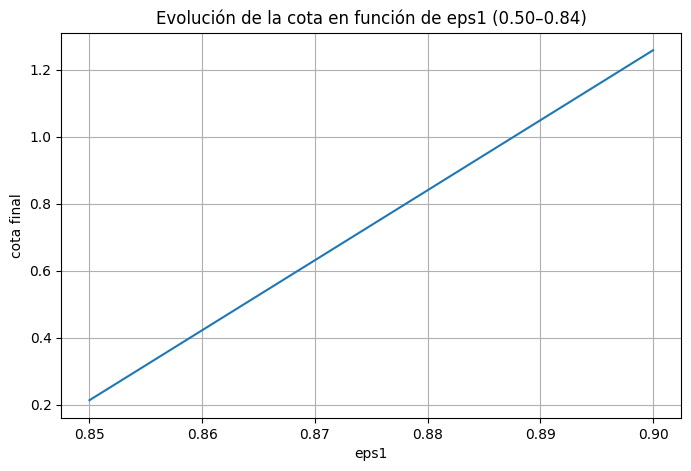

In [92]:
import matplotlib.pyplot as plt
eps1_vals = np.arange(0.850, 0.9, 0.001)  
cota_vals = []

for eps1 in eps1_vals:
    delta_eps = abs(eps1 - eps0)
    norm_b_1 = delta_eps * p_bar
    cota = norm_u_inf * norm_b_1 / (346 * 346)
    cota_vals.append(cota)

plt.figure(figsize=(8, 5))
plt.plot(eps1_vals, cota_vals)
plt.xlabel("eps1")
plt.ylabel("cota final")
plt.title("Evolución de la cota en función de eps1 (0.50–0.84)")
plt.grid(True)
plt.show()

In [27]:
ind_rows = filas_independientes_sparse_gauss(A_leq, C)
print("Filas independientes:", len(ind_rows))

nA = A_leq.shape[0]

ind_A = [i for i in ind_rows if i < nA]
ind_C = [i - nA for i in ind_rows if i >= nA]

A_LI = A_leq[ind_A, :]
C_LI = C[ind_C, :]


Filas procesadas: 100%|██████████| 267299/267299 [01:52<00:00, 2366.75fila/s]

Filas independientes: 120062


In [30]:

b_LI = b_leq[ind_A]

d_LI = d[ind_C]


In [41]:
sol2 = modelo_distancia(x1, A_LI, b_LI, C_LI, d_LI)

Set parameter OutputFlag to value 1
Set parameter Method to value 1
Set parameter BarHomogeneous to value 1
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-1355U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
Method  1
BarHomogeneous  1

Optimize a model with 480248 rows, 240124 columns and 959804 nonzeros
Model fingerprint: 0x5c2bd9e9
Coefficient statistics:
  Matrix range     [1e+00, 1e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-03, 1e+00]
Presolve removed 480248 rows and 240124 columns
Presolve time: 0.27s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.40 seconds (0.63 work units)
Optimal objective  0.000000000e+00


In [ ]:

norm_u_1 = np.sum(np.abs(sol2["u"]))
print("||u||_1 =", norm_u_1) 

||u||_1 = 0.0


In [48]:
print(np.max(np.abs(sol2["u"])))

0.0


---

In [17]:

up_rows, lo_rows = detect_population_rows(meta, b_leq)
phat_est, eps_est = estimate_phat_eps(b_leq, up_rows, lo_rows)


In [18]:

print(f"pop_up rows: {len(up_rows)}  (esperado ≈ |C|)")
print(f"pop_lo rows: {len(lo_rows)}  (esperado ≈ |C|)")
print(f"phat_est ≈ {phat_est:.4f}   eps_est ≈ {eps_est:.4f}")


pop_up rows: 120062  (esperado ≈ |C|)
pop_lo rows: 0  (esperado ≈ |C|)
phat_est ≈ 0.0000   eps_est ≈ 0.0000


In [19]:

# mira algunos índices/valores para confirmar
print("muestras up_rows:", up_rows[:5], "b:", [float(b_leq[r]) for r in up_rows[:5]])
print("muestras lo_rows:", lo_rows[:5], "b:", [float(b_leq[r]) for r in lo_rows[:5]])

muestras up_rows: [0, 1, 2, 3, 4] b: [0.0, 0.0, 0.0, 0.0, 0.0]
muestras lo_rows: [] b: []


In [20]:
from funciones import pob
# Verificación directa de phat = (sum_i poblacion_i) / |C|

total_pop = sum(pob(comunas, i) for i in R)
K = len(up_rows)  # |C|, coincide con filas de población por arriba
phat_true = total_pop / K

print(f"phat_true = {phat_true:.4f}")
print(f"phat_est  = {phat_est:.4f}")
print(f"abs diff  = {abs(phat_true - phat_est):.4f}")
print(f"rel diff  = {abs(phat_true - phat_est)/max(1.0, phat_true):.6f}")


phat_true = 145.9162
phat_est  = 0.0000
abs diff  = 145.9162
rel diff  = 1.000000


In [21]:
# Construir \Delta b para pasar de eps_ref -> eps_new
eps_ref = eps_est  # = 0.95
eps_new = 0.8398          # ejemplo

delta_eps = float(eps_new - eps_ref)
Delta_b = np.zeros_like(b_leq, dtype=float)

# Mismo incremento en filas up y lo ( lo ya está normalizada a "<=")
Delta_b[up_rows] += phat_est * delta_eps
Delta_b[lo_rows] += phat_est * delta_eps


In [22]:

print("Δb nnz:", np.count_nonzero(Delta_b), " (esperado ~", 2*len(up_rows), ")")
print("valor Δb esperado por fila de población:", phat_est*delta_eps)
print("chequeo primeras 3 filas up:", Delta_b[up_rows[:3]])
print("chequeo primeras 3 filas lo:", Delta_b[lo_rows[:3]])


Δb nnz: 0  (esperado ~ 240124 )
valor Δb esperado por fila de población: 0.0
chequeo primeras 3 filas up: [0. 0. 0.]
chequeo primeras 3 filas lo: []
